<a href="https://colab.research.google.com/github/ramsaher/DEVF_Master_Ciencias_de_Datos/blob/main/Leccion_6_Hands_On_Exploraci%C3%B3n_de_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **HANDS - ON: EXPLORACIÓN DE DATOS**



Una vez visto la presentación ***Exploración de datos***, se proporciona el siguiente ***colab*** para que **el alumnado pueda practicar** haciendo uso del lenguaje de programación ***python***.

Para este notebook, se hará uso del siguiente dataset: [enlace](https://drive.google.com/file/d/1hX8uxJp5h03eYrgAnyznp8yeeG2syiD_/view?usp=drive_link)

De igual manera, se proporciona la **solución** de este notebook a través del siguiente [enlace](https://colab.research.google.com/drive/1eXIB1nd8aaBZWDYBXlIlfCOVkAe-ETrI?usp=drive_link).

## **ANÁLISIS EXPLORATPRIO**

El **Análisis Exploratorio de Datos (EDA)** es la etapa donde **se descubren patrones, se detectan anomalías y se comprueban hipótesis mediante estadísticas y visualizaciones**. Es el proceso fundamental para entender la salud de la información antes de cualquier toma de decisiones.

A través de herramientas descriptivas y gráficos de dispersión, esta fase permite limpiar inconsistencias y validar la calidad de la muestra. Su ejecución garantiza que las conclusiones posteriores se apoyen en evidencia real, minimizando sesgos y optimizando la precisión de los modelos predictivos.

In [1]:
# Importar librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración para ver todas las columnas y filas (sin que se corten)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print(" Librerías importadas correctamente")


 Librerías importadas correctamente


In [2]:
# Importar datos

# Importar dataset
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [5]:
ruta_colab = '/content/MyDrive/'
df_youtube= pd.read_csv('/content/drive/MyDrive/youtube_clean.csv')

print("Dataset cargado exitosamente")
print(f"Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas")

Dataset cargado exitosamente
Dimensiones: 308 filas, 9 columnas


In [6]:
# Mostrar las primeras filas para ver cómo son los datos

print(" PRIMERAS 5 FILAS DEL DATASET:")
print(df_youtube.head())
print("\n" + "="*50)
print(f"📏 DIMENSIÓN DEL DATASET: {df_youtube.shape[0]} filas y {df_youtube.shape[1]} columnas")
print("="*50)

 PRIMERAS 5 FILAS DEL DATASET:
   video_id      título  categoría   views  likes  dislikes  comentarios  \
0         1      título     música  129257  11299        21         8790   
1         2      título  películas  247904  15579       211         4775   
2         3  sin título    comedia    3073  14780      1095         9847   
3         4      título     gaming  268858   2691      4420         7614   
4         5      título     gaming  162893  16521      2294         6508   

   duración_min fecha_publicación  
0           127        2024-07-02  
1            63        2022-02-13  
2            55        2016-07-06  
3            78        2017-12-03  
4           143        2023-11-24  

📏 DIMENSIÓN DEL DATASET: 308 filas y 9 columnas


In [8]:
# Mostrar nombres de las columnas para entender qué información tenemos

print("\n COLUMNAS DISPONIBLES:")
print(df_youtube.columns.tolist())


 COLUMNAS DISPONIBLES:
['video_id', 'título', 'categoría', 'views', 'likes', 'dislikes', 'comentarios', 'duración_min', 'fecha_publicación']


In [13]:
# Ver resumen estadístico de las columnas numéricas

columnas_numericas = ['views', 'likes', 'dislikes', 'comentarios', 'duración_min']
df_youtube[columnas_numericas].describe()


,views,likes,dislikes,comentarios,duración_min
count,308.000000,3.080000e+02,308.000000,308.000000,308.000000
mean,144805.269481,6.265995e+05,12193.288961,5058.188312,139.853896
std,86246.543475,2.407311e+06,52900.153300,2940.396104,139.066834
min,1691.000000,9.700000e+01,21.000000,12.000000,1.000000
25%,74129.500000,5.774250e+03,1523.750000,2667.500000,58.000000
50%,129257.000000,1.129900e+04,2590.000000,4931.500000,123.500000
75%,224050.750000,1.575300e+04,3777.500000,7740.750000,181.500000
max,299408.000000,9.999999e+06,300408.000000,9987.000000,800.000000


In [14]:
# Información adicional sobre tipos de datos y valores nulos

print("\n INFORMACIÓN DEL DATAFRAME:")
print(df_youtube.info())


 INFORMACIÓN DEL DATAFRAME:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   video_id           308 non-null    int64 
 1   título             308 non-null    object
 2   categoría          308 non-null    object
 3   views              308 non-null    int64 
 4   likes              308 non-null    int64 
 5   dislikes           308 non-null    int64 
 6   comentarios        308 non-null    int64 
 7   duración_min       308 non-null    int64 
 8   fecha_publicación  308 non-null    object
dtypes: int64(6), object(3)
memory usage: 21.8+ KB
None


### **VALORES ATÍPICOS Y TRATAMIENTO**

**Los valores atípicos son observaciones que se alejan significativamente del resto de los datos**. Pueden ser causados por errores en la entrada de datos o por fenómenos naturales del dataset.

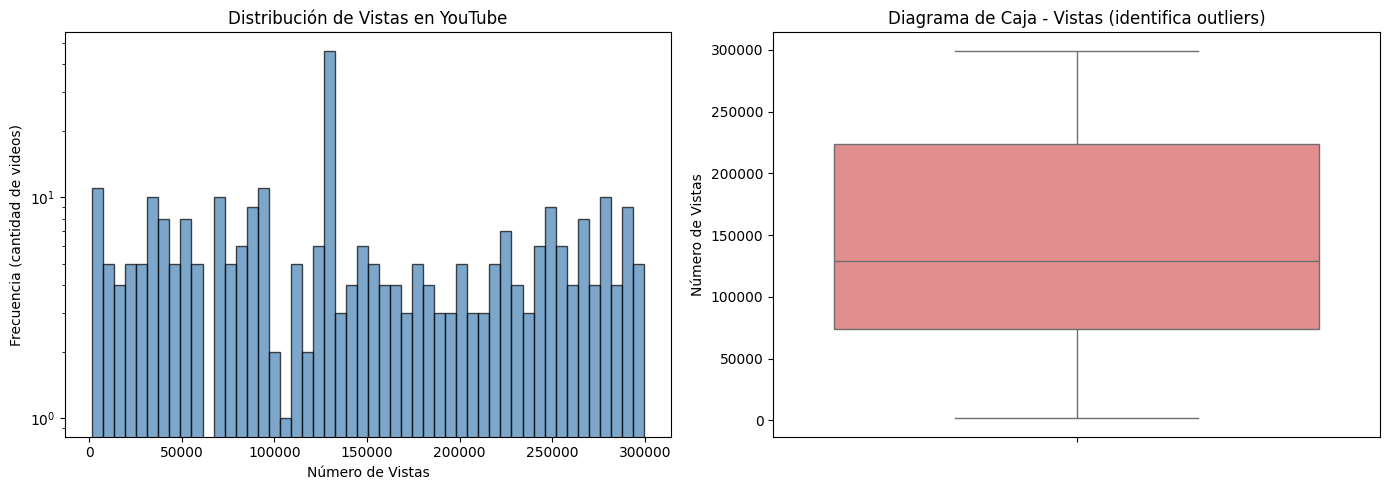

💡 INTERPRETACIÓN:
- El histograma muestra que la mayoría de videos tienen pocas vistas
- El boxplot revela puntos fuera de los 'bigotes' → esos son OUTLIERS


In [15]:
# Observar distribución de los datos

#  VISUALIZAR DISTRIBUCIÓN DE DATOS (HISTOGRAMA Y BOXPLOT)
# Antes de detectar outliers, veamos cómo se distribuyen los datos

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Histograma de 'views' (vistas)

# El histograma muestra cuántos videos tienen cierta cantidad de vistas

axes[0].hist(df_youtube['views'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Número de Vistas')
axes[0].set_ylabel('Frecuencia (cantidad de videos)')
axes[0].set_title('Distribución de Vistas en YouTube')
axes[0].set_yscale('log')  # Escala logarítmica para ver mejor datos muy grandes

# Gráfico 2: Boxplot de 'views'
# El boxplot muestra: mínimo, Q1, mediana, Q3, máximo y outliers

sns.boxplot(y=df_youtube['views'], ax=axes[1], color='lightcoral')
axes[1].set_ylabel('Número de Vistas')
axes[1].set_title('Diagrama de Caja - Vistas (identifica outliers)')

plt.tight_layout()
plt.show()

print(" INTERPRETACIÓN:")
print("- El histograma muestra que la mayoría de videos tienen pocas vistas")
print("- El boxplot revela puntos fuera de los 'bigotes' → esos son OUTLIERS")


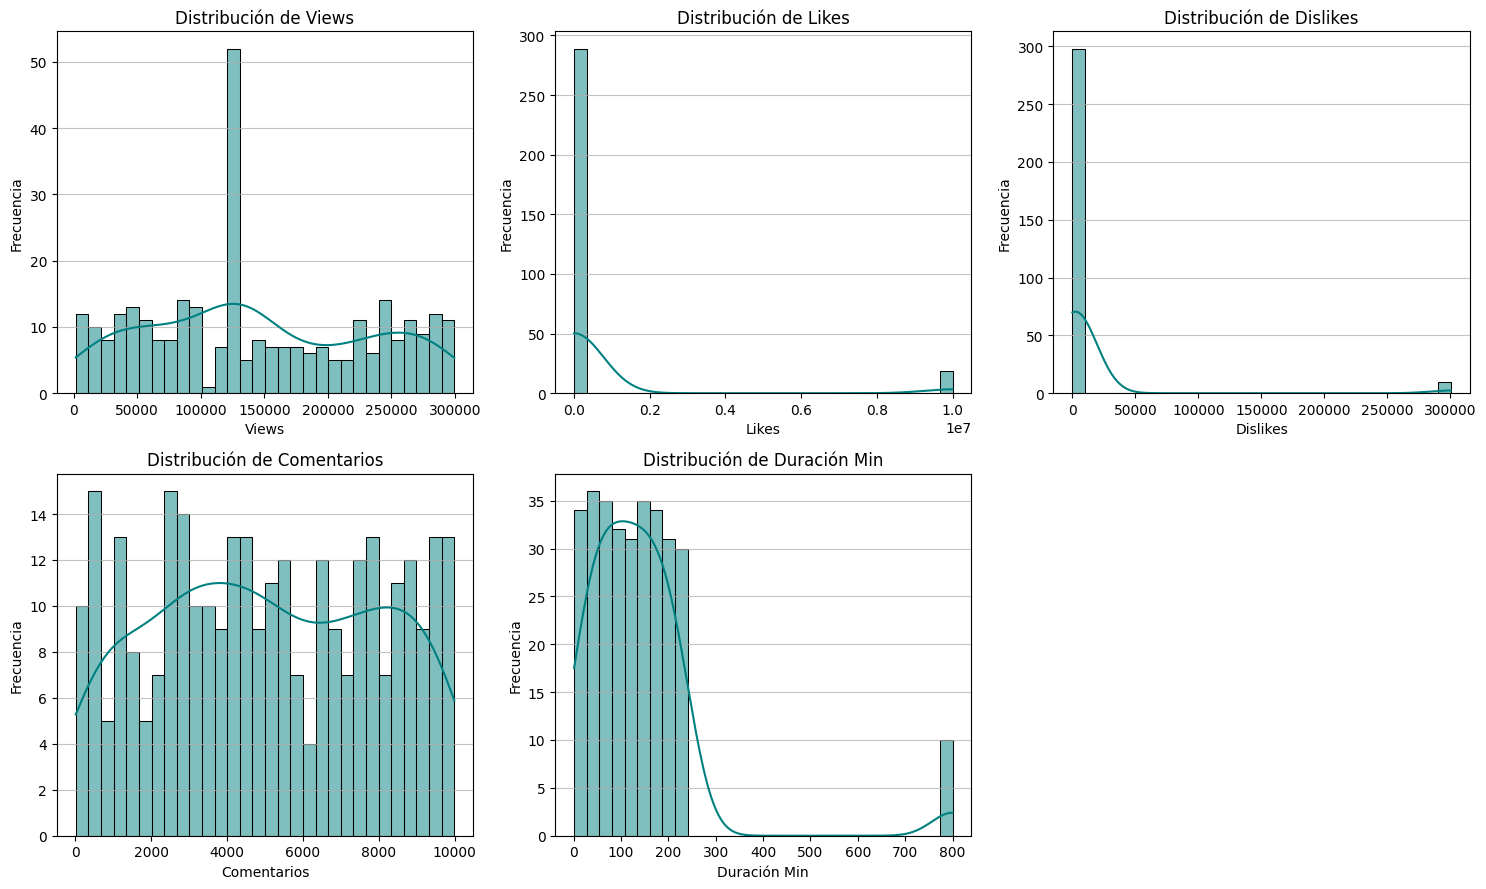

In [20]:
# Observar distribución de los datos

plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_youtube[col], bins=30, kde=True, color='teal')
    plt.title(f'Distribución de {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

# Todas las distribuciones no son normales y casi todos tienen valores extremos

In [64]:
# Observar comportamiento cuartil de los datos

# Los cuartiles dividen los datos en 4 partes iguales (25% cada una)

# Calcular cuartiles específicamente para la columna 'views'

Q1_views = df_youtube['views'].quantile(0.25)  # Primer cuartil (25%)
Q2_views = df_youtube['views'].quantile(0.50)  # Mediana (50%)
Q3_views = df_youtube['views'].quantile(0.75)  # Tercer cuartil (75%)

print(" ESTADÍSTICAS DE LA COLUMNA 'views':")
print(f"  Mínimo: {df_youtube['views'].min():,.0f}")
print(f"  Cuartil 1 (Q1 - 25%): {Q1_views:,.0f}")
print(f"  Mediana (Q2 - 50%): {Q2_views:,.0f}")
print(f"  Cuartil 3 (Q3 - 75%): {Q3_views:,.0f}")
print(f"  Máximo: {df_youtube['views'].max():,.0f}")
print(f"  Media (promedio): {df_youtube['views'].mean():,.0f}")


# Calcular también para la columna 'likes'
print("\n ESTADÍSTICAS DE LA COLUMNA 'likes':")
print(f"  Mínimo: {df_youtube['likes'].min():,.0f}")
print(f"  Q1: {df_youtube['likes'].quantile(0.25):,.0f}")
print(f"  Mediana: {df_youtube['likes'].quantile(0.50):,.0f}")
print(f"  Q3: {df_youtube['likes'].quantile(0.75):,.0f}")
print(f"  Máximo: {df_youtube['likes'].max():,.0f}")
print(f"  Media: {df_youtube['likes'].mean():,.0f}")

 ESTADÍSTICAS DE LA COLUMNA 'views':
  Mínimo: 1,691
  Cuartil 1 (Q1 - 25%): 74,130
  Mediana (Q2 - 50%): 129,257
  Cuartil 3 (Q3 - 75%): 224,051
  Máximo: 299,408
  Media (promedio): 144,805

 ESTADÍSTICAS DE LA COLUMNA 'likes':
  Mínimo: 97
  Q1: 5,774
  Mediana: 11,299
  Q3: 15,753
  Máximo: 9,999,999
  Media: 626,600


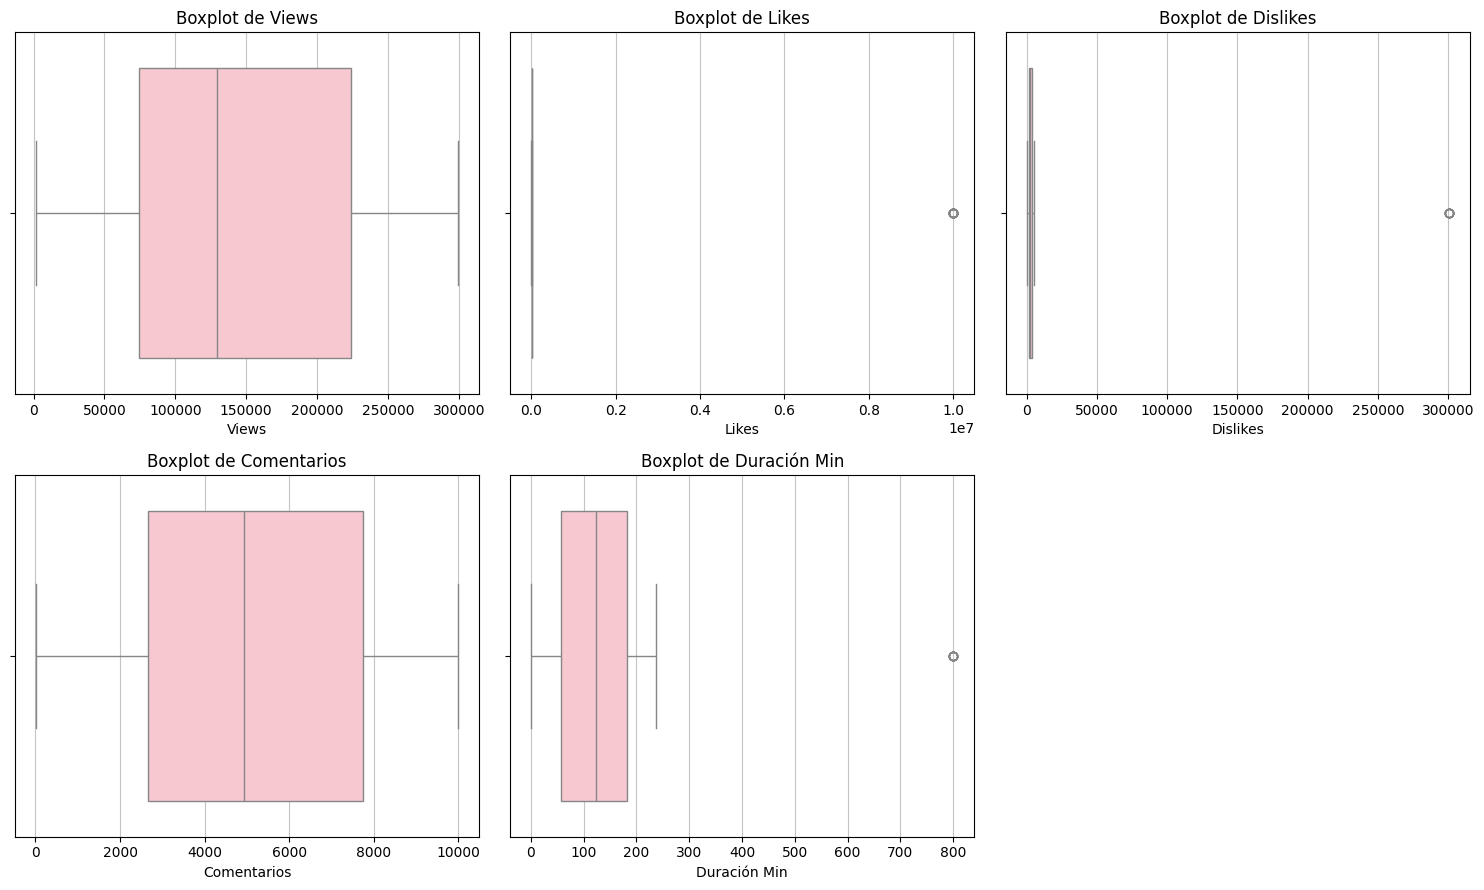

In [21]:
# Observar comportamiento cuartil de los datos

plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df_youtube[col], color='pink')
    plt.title(f'Boxplot de {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.grid(axis='x', alpha=0.75)

plt.tight_layout()
plt.show()

# Tres gráficos de caja presentan valores extremos

#### **RANGO INTERCUARTILICO**

El **Rango Intercuartílico (IQR)** es una medida fundamental de dispersión estadística, utilizada principalmente para detectar y manejar **valores atípicos (outliers)** en un conjunto de datos. Se calcula como la diferencia entre el tercer cuartil (Q3) y el primer cuartil (Q1):

$$IQR = Q3 - Q1$$

Para identificar outliers, se definen límites:

*   **Límite Inferior (LI):** $LI = Q1 - 1.5 \times IQR$

*   **Límite Superior (LS):** $LS = Q3 + 1.5 \times IQR$


In [65]:
# Ver cantidad de registros iniciales

registros_iniciales = len(df_youtube)
print(f" REGISTROS INICIALES: {registros_iniciales:,}")

# Mostrar algunos datos nulos (si los hay)
print(f"\n VALORES NULOS POR COLUMNA:")
print(df_youtube.isnull().sum())


 REGISTROS INICIALES: 308

 VALORES NULOS POR COLUMNA:
video_id             0
título               0
categoría            0
views                0
likes                0
dislikes             0
comentarios          0
duración_min         0
fecha_publicación    0
agrupacion_cat       0
dtype: int64


In [66]:

# CÁLCULO DEL RANGO INTERCUARTÍLICO (IQR)

# El IQR = Q3 - Q1. Mide la dispersión del 50% central de los datos.
# Para detectar outliers: valores fuera de [Q1 - 1.5*IQR, Q3 + 1.5*IQR]

def detectar_outliers_iqr(df, columna):
    """
    Detecta y filtra outliers usando el método del Rango Intercuartílico

    ¿Cómo funciona?
    1. Calcula Q1 (percentil 25) y Q3 (percentil 75)
    2. IQR = Q3 - Q1
    3. Límite inferior = Q1 - 1.5 * IQR
    4. Límite superior = Q3 + 1.5 * IQR
    5. Valores fuera de estos límites son OUTLIERS
    """
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Contar outliers
    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
    n_outliers = len(outliers)

    print(f"\n ANÁLISIS DE OUTLIERS - COLUMNA: {columna}")
    print(f"  Q1 (25%): {Q1:,.2f}")
    print(f"  Q3 (75%): {Q3:,.2f}")
    print(f"  IQR: {IQR:,.2f}")
    print(f"  Límite Inferior: {limite_inferior:,.2f}")
    print(f"  Límite Superior: {limite_superior:,.2f}")
    print(f"  Cantidad de Outliers: {n_outliers}")
    print(f"  Porcentaje de Outliers: {n_outliers/len(df)*100:.2f}%")

    return limite_inferior, limite_superior, n_outliers

# Aplicar a las columnas numéricas principales
columnas_a_analizar = ['views', 'likes', 'comentarios']

for col in columnas_a_analizar:
    detectar_outliers_iqr(df_youtube, col)


 ANÁLISIS DE OUTLIERS - COLUMNA: views
  Q1 (25%): 74,129.50
  Q3 (75%): 224,050.75
  IQR: 149,921.25
  Límite Inferior: -150,752.38
  Límite Superior: 448,932.62
  Cantidad de Outliers: 0
  Porcentaje de Outliers: 0.00%

 ANÁLISIS DE OUTLIERS - COLUMNA: likes
  Q1 (25%): 5,774.25
  Q3 (75%): 15,753.00
  IQR: 9,978.75
  Límite Inferior: -9,193.88
  Límite Superior: 30,721.12
  Cantidad de Outliers: 19
  Porcentaje de Outliers: 6.17%

 ANÁLISIS DE OUTLIERS - COLUMNA: comentarios
  Q1 (25%): 2,667.50
  Q3 (75%): 7,740.75
  IQR: 5,073.25
  Límite Inferior: -4,942.38
  Límite Superior: 15,350.62
  Cantidad de Outliers: 0
  Porcentaje de Outliers: 0.00%


In [28]:
# Calculo del IQR

# Creamos una copia del dataframe original para no perder datos

df_copy = df_youtube.copy() # preservar el dataset haciendo una copia

for col in columnas_numericas:

    Q1 = df_copy[col].quantile(0.25) # Primer cuartil
    Q3 = df_copy[col].quantile(0.75) # Tercer cuartil
    IQR = Q3 - Q1 # Rango Intercuartilico

    lim_inf_iqr = Q1 - 1.5 * IQR # Límite inferior
    lim_sup_iqr = Q3 + 1.5 * IQR # Límite superior

    cant_inicial = len(df_copy)
    # Filtro de los datos dentro de los límites
    df_copy = df_copy[(df_copy[col] >= lim_inf_iqr) & (df_copy[col] <= lim_sup_iqr)]
    cant_final = len(df_copy)

    print(f"Columna '{col}': Se eliminaron {cant_inicial - cant_final} registros.")

Columna 'views': Se eliminaron 0 registros.
Columna 'likes': Se eliminaron 19 registros.
Columna 'dislikes': Se eliminaron 10 registros.
Columna 'comentarios': Se eliminaron 0 registros.
Columna 'duración_min': Se eliminaron 10 registros.


In [30]:
# Ver cantidad de registros finales y proporción con la cantidad inicial

prop_cant_datos = round((len(df_copy) / len(df_youtube)) * 100, 2)

print(f"Cantidad de datos finales: {len(df_copy)}")
print(f"Los datos finales representan el {prop_cant_datos}% de los datos iniciales")

Cantidad de datos finales: 269
Los datos finales representan el 87.34% de los datos iniciales


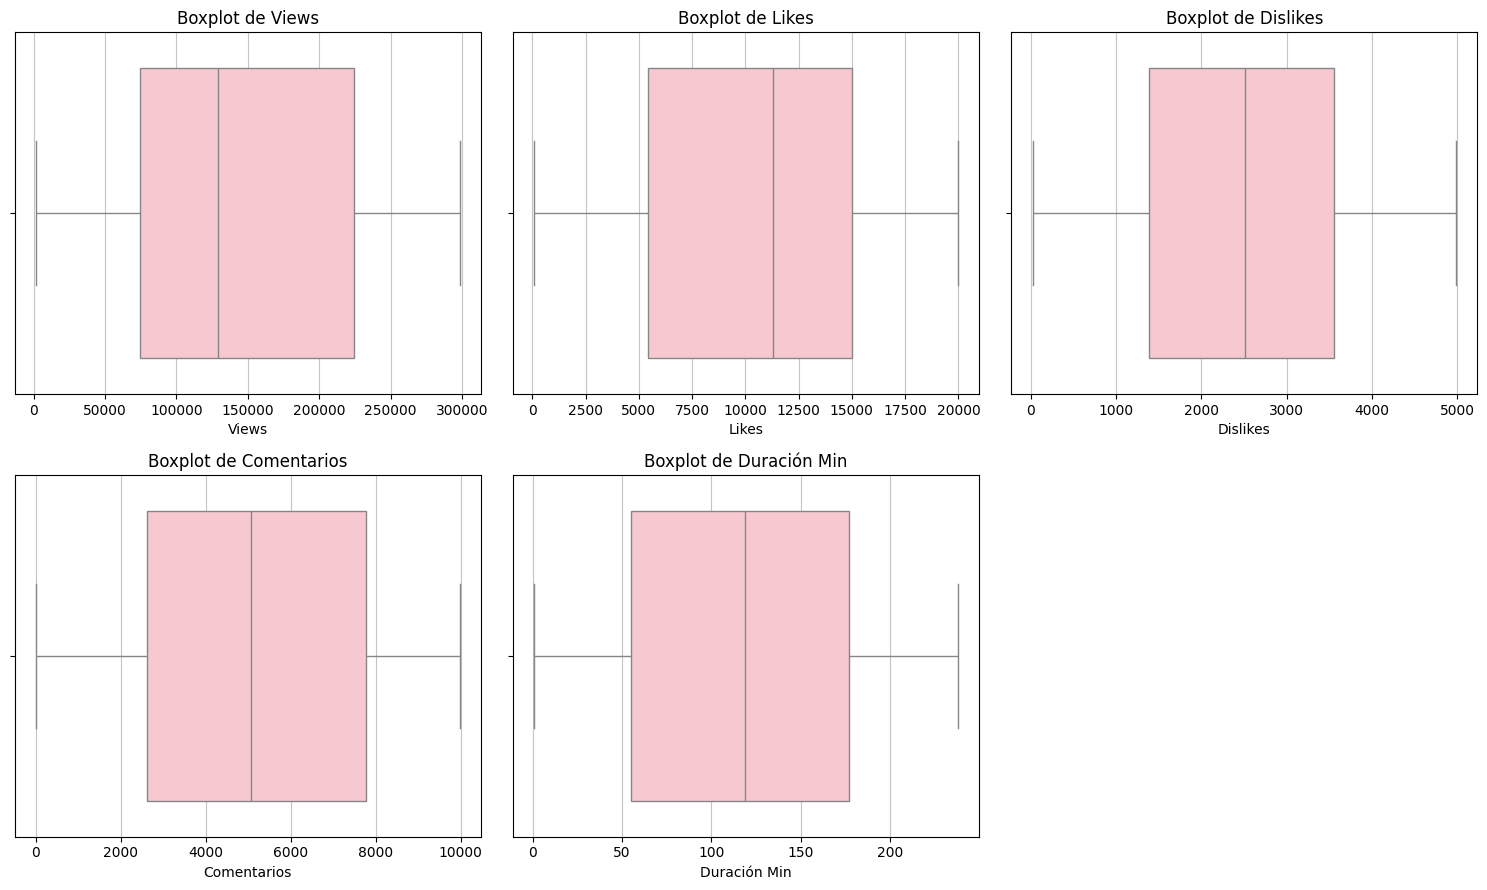

In [31]:
# Observar comportamiento cuartil final de los datos


### **CORRELACIÓN NUMÉRICA**

La **correlación numérica** es una medida estadística que **indica la fuerza y dirección de la relación lineal entre dos o más variables numéricas**. Puede utilizar el coeficiente de correlación de Pearson (el más común) para determinar la dirección (positiva, negativa, nula).

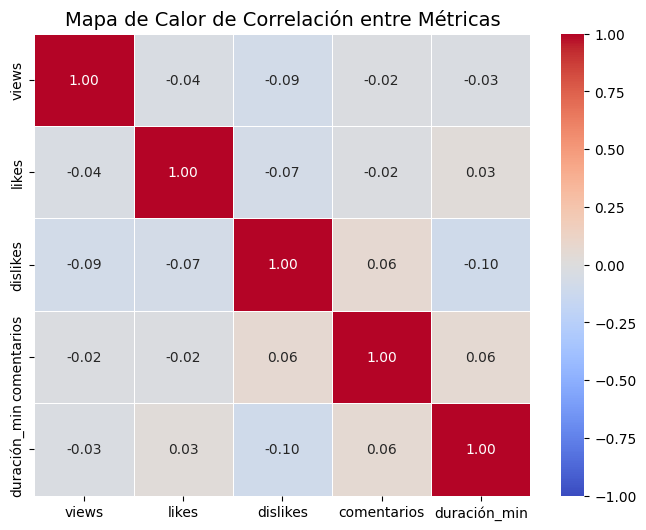

In [34]:
# Realizar matriz de correlación

corr_matrix = df_copy[['views', 'likes', 'dislikes', 'comentarios', 'duración_min']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Mapa de Calor de Correlación entre Métricas', fontsize=14)
plt.show()

# Los coeficientes de las intersecciones convergen en 0, no hay correlación

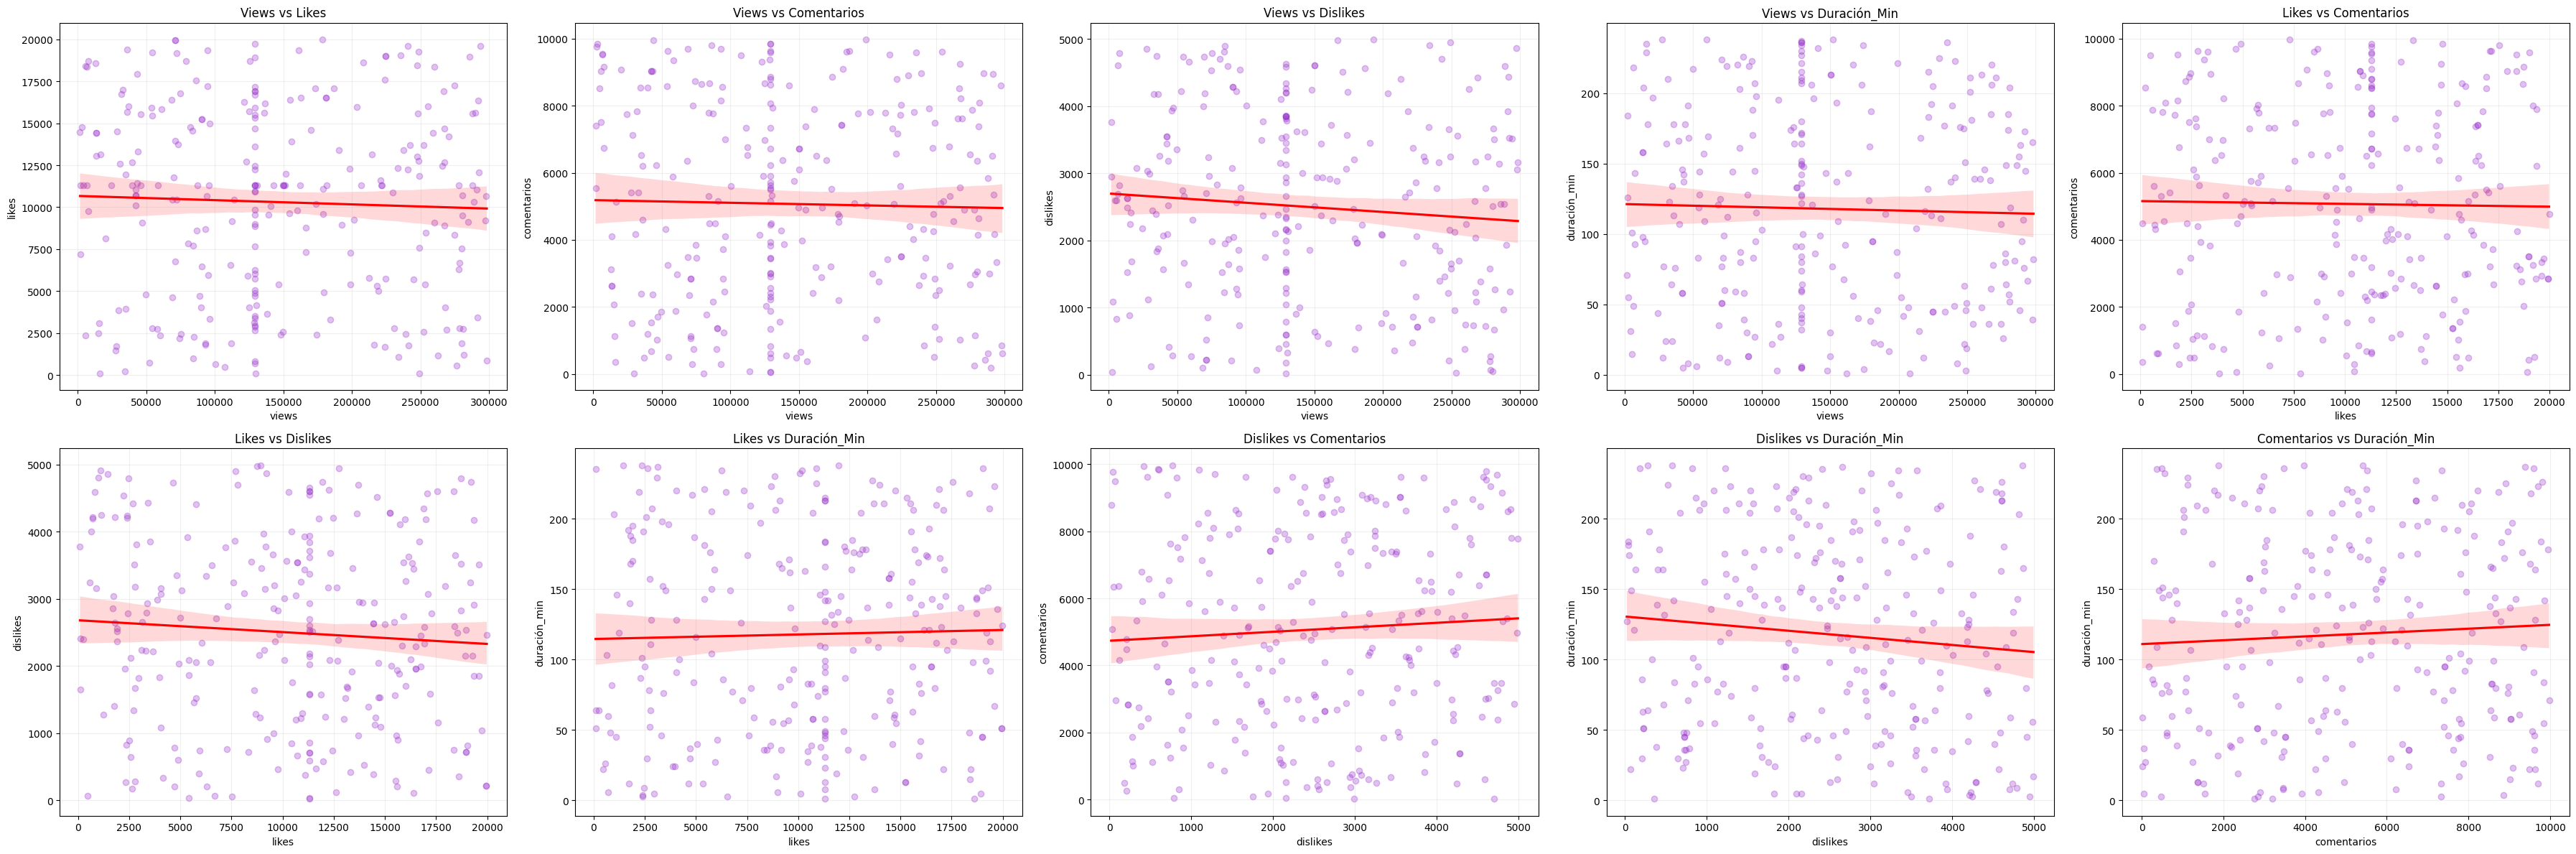

In [35]:
# Realizar correlaciones divididas

metricas = ['views', 'likes', 'dislikes', 'comentarios', 'duración_min']

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(36, 12))
axes = axes.flatten() # Aplanamos para iterar fácilmente

# Pares de comparación por
comparaciones = [
    ('views', 'likes'), ('views', 'comentarios'), ('views', 'dislikes'),
    ('views', 'duración_min'), ('likes', 'comentarios'), ('likes', 'dislikes'),
    ('likes', 'duración_min'), ('dislikes', 'comentarios'),
    ('dislikes', 'duración_min'), ('comentarios', 'duración_min')
]

for i, (col_x, col_y) in enumerate(comparaciones):
    sns.regplot(ax=axes[i], data=df_copy, x=col_x, y=col_y,
                scatter_kws={'alpha':0.3, 'color':'darkorchid'},
                line_kws={'color':'red'})
    axes[i].set_title(f'{col_x.title()} vs {col_y.title()}')
    axes[i].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Al no haber correlaciones, los datos se muestran dispersos

#### **COMPARACIÓN POR CATEGÓRICA**

La **comparación por categórica** implica analizar cómo las variables numéricas se comportan o distribuyen a través de diferentes grupos o categorías. Este tipo de análisis es fundamental para entender: **distribuciones, tendencias y relaciones**

Para visualizar estas comparaciones, son muy útiles los **gráficos de barras**, donde se pueden mostrar las cantidades o promedios de una variable numérica para cada categoría, o los **diagramas de caja (boxplots)**, que revelan la distribución completa de los datos dentro de cada grupo, incluyendo la mediana, cuartiles y posibles valores atípicos.

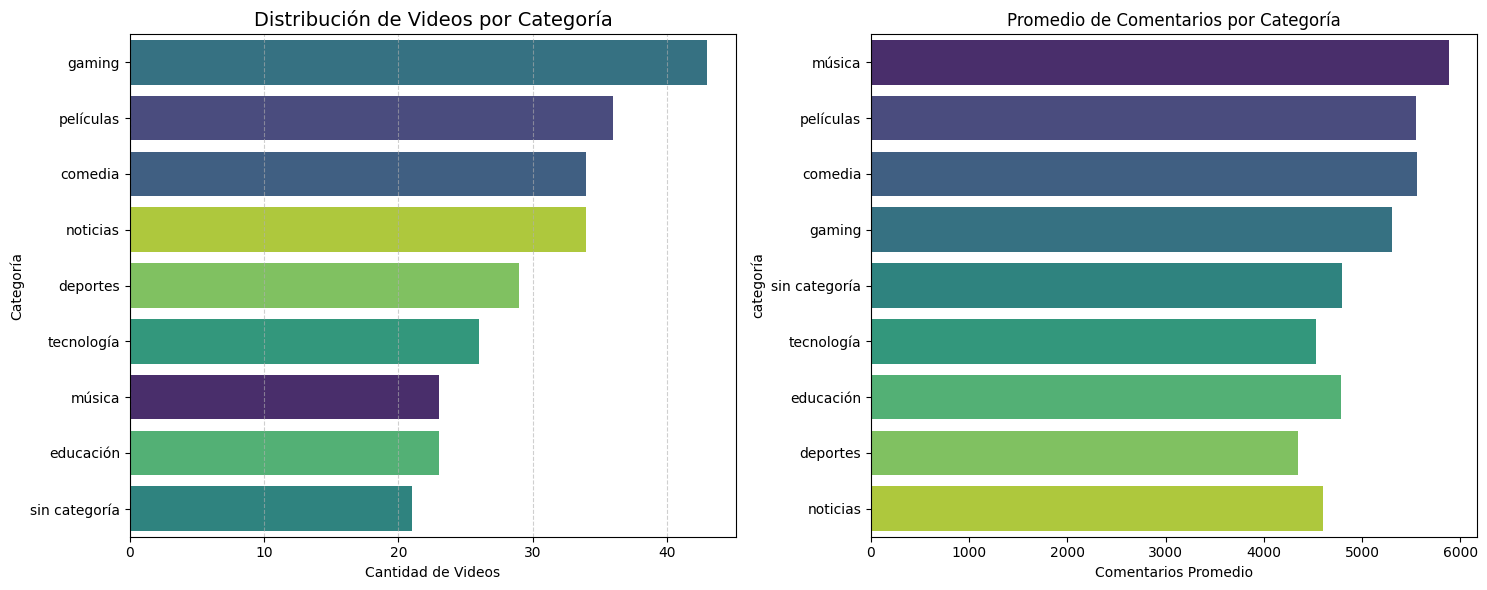

In [36]:
# Realizar gráficos de barras divididas

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
orden = df_copy['categoría'].value_counts().index # Ordenar de mayor a menor
sns.countplot(data=df_copy, y='categoría', order=orden, palette='viridis', hue='categoría', legend=False)
plt.title('Distribución de Videos por Categoría', fontsize=14)
plt.xlabel('Cantidad de Videos')
plt.ylabel('Categoría')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
sns.barplot(data=df_copy, x='comentarios', y='categoría',
            estimator='mean', palette='viridis', errorbar=None, hue='categoría', legend=False)
plt.title('Promedio de Comentarios por Categoría')
plt.xlabel('Comentarios Promedio')

plt.tight_layout()
plt.show()


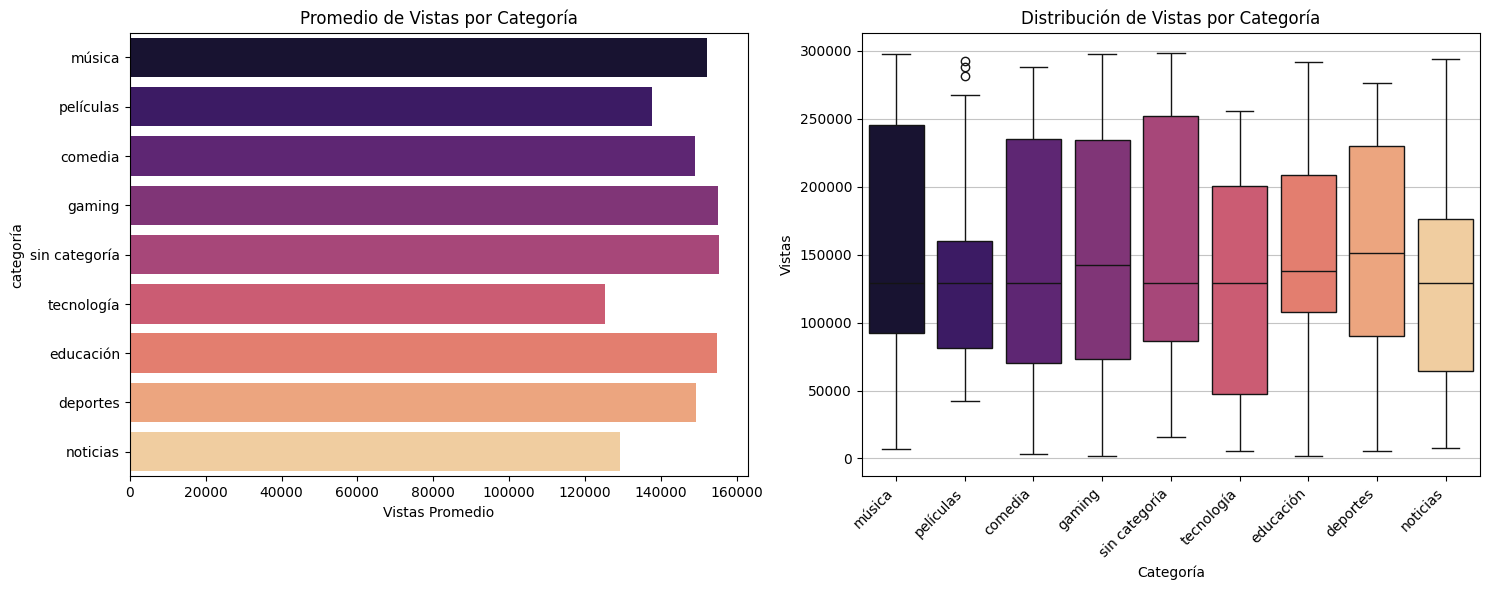

In [37]:
# Realizar gráfico de barras y caja divididos

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=df_copy, x='views', y='categoría',
            estimator='mean', palette='magma', errorbar=None, hue='categoría', legend=False)
plt.title('Promedio de Vistas por Categoría')
plt.xlabel('Vistas Promedio')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_copy, x='categoría', y='views', palette='magma', hue='categoría', legend=False)
plt.title('Distribución de Vistas por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Vistas')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()


## **NARRATIVA VISUAL**

La **visualización narrativa** es la fusión estratégica entre la **claridad de los gráficos** y el **impacto del storytelling para comunicar mensajes** memorables. No se limita a exponer cifras, sino que construye un relato donde los datos actúan como evidencia para guiar a la audiencia hacia una conclusión clara.

Al conectar puntos de datos con una estructura narrativa, se logra captar la atención emocional y lógica del espectador. Esta técnica transforma estadísticas frías en una historia coherente, facilitando la comprensión de tendencias complejas y asegurando que los hallazgos clave impulsen una toma de decisiones informada.

### **PROPORCIÓN DE DATOS A MOSTRAR**

In [39]:
# Definir variables para la agrupación
categoria = lambda x: 'Sin Categoría' if x == 'sin categoría' else 'Con Categoría'
df_youtube['agrupacion_cat'] = df_youtube['categoría'].apply(categoria)
pie_data = df_youtube['agrupacion_cat'].value_counts()


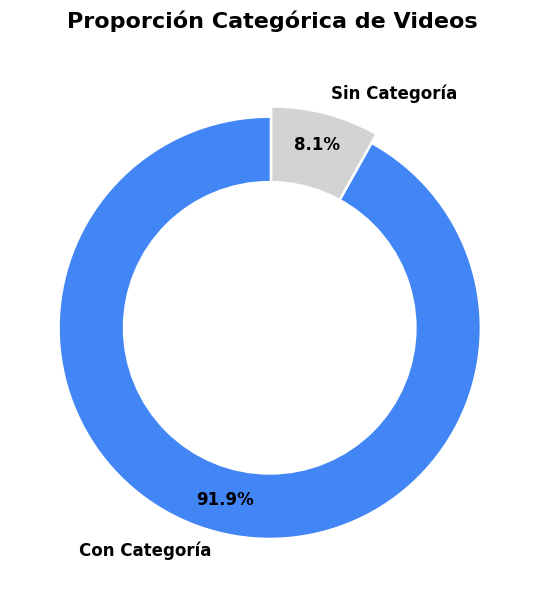

In [41]:
# Realizar gráfico de dona

colors_pie = ['#4285F4', '#D3D3D3'] # Azul = "Con Categoría", Gris = "Sin Categoría"
explode_val = 0.05 # Valor de separación

# Gráfico de pastel

plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(pie_data,
                                   labels=pie_data.index,
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   colors=colors_pie,
                                   textprops={'fontsize': 12, 'fontweight': 'bold'},
                                   pctdistance=0.85, # Mueve el porcentaje hacia afuera
                                   explode=(explode_val, 0)) # Resalta ligeramente la porción principal

# Círculo blanco central (estilo moderno)

theta1, theta2 = wedges[0].theta1, wedges[0].theta2
center_angle = np.deg2rad((theta1 + theta2) / 2) # Obtención el ángulo medio

cx = explode_val * np.cos(center_angle) # Se Calcula nueva posición con trigonometría
cy = explode_val * np.sin(center_angle)

centre_circle = plt.Circle((cx, cy), 0.70, fc='white') # Se dibuja el circulo
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Proporción Categórica de Videos', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


### **DISTRIBUCIÓN DE VÍDEOS POR CATEGORÍA**

In [43]:
# Definir variables

df_filtrado = df_youtube[df_youtube['categoría'] != 'sin categoría']
counts = df_filtrado['categoría'].value_counts()
order = counts.index
values = counts.values

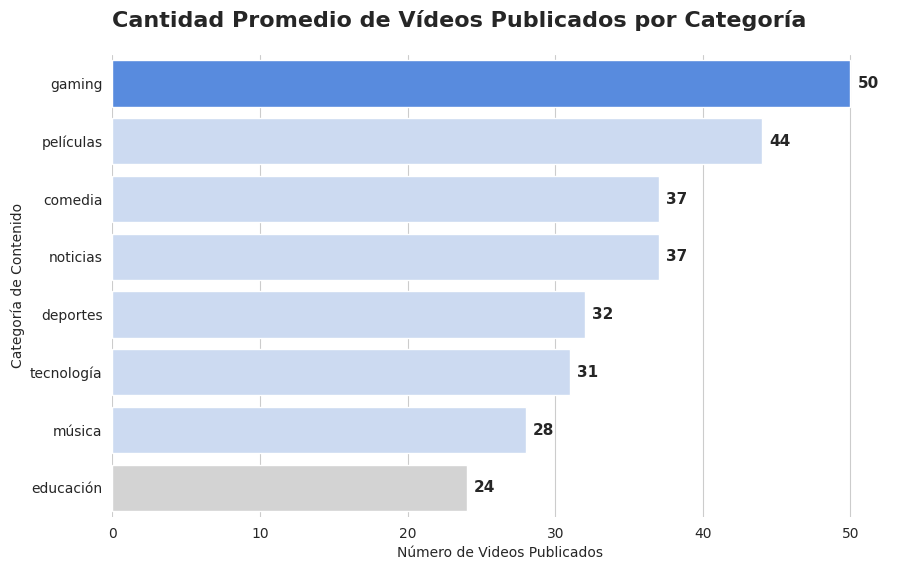

In [44]:
# Realizar gráfico de barras

colors = ['#4285F4' if v == values.max() else '#D3D3D3' if v == values.min() else '#C6D9F7' for v in values]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x=values, y=order, palette=colors, hue=order, legend=False)

for p in ax.patches: # Etiquetas de datos
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=11, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Cantidad Promedio de Vídeos Publicados por Categoría', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Número de Videos Publicados')
plt.ylabel('Categoría de Contenido')
sns.despine(left=True, bottom=True)
plt.show()


### **PROMEDIO DE VISTAS POR CATEGORÍA**

In [47]:
# Definir variables

vistas_mean = df_youtube.groupby('categoría')['views'].mean().sort_values(ascending=False)
colors_vistas = ['#4285F4' if v == vistas_mean.max() else '#D3D3D3' if v == vistas_mean.min() else '#C6D9F7' for v in vistas_mean]




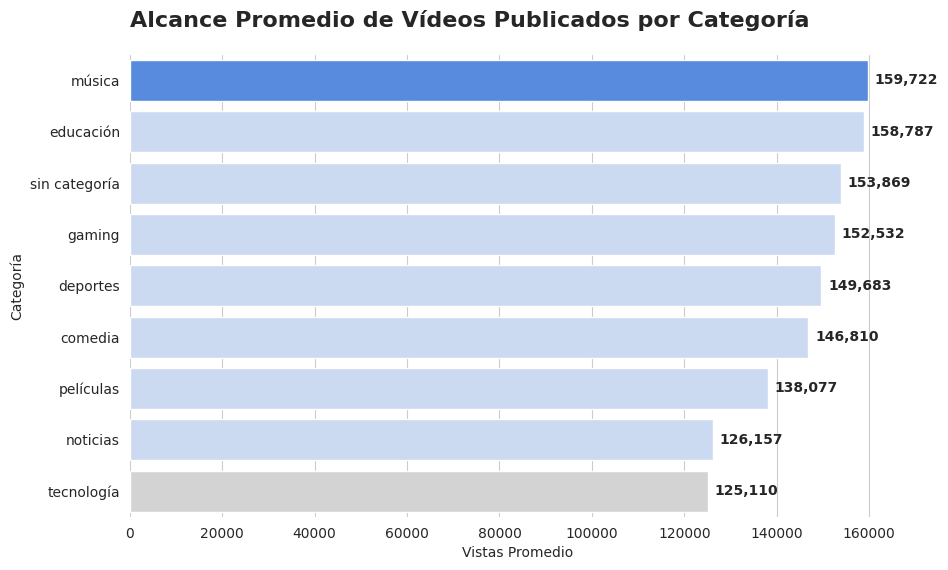

In [48]:
# Realizar gráfico de barras

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax1 = sns.barplot(x=vistas_mean.values, y=vistas_mean.index, palette=colors_vistas, hue=vistas_mean.index, legend=False)

for p in ax1.patches: # Etiquetas y estética
    ax1.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Alcance Promedio de Vídeos Publicados por Categoría', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Vistas Promedio')
plt.ylabel('Categoría')
sns.despine(left=True, bottom=True)
plt.show()


### **PROMEDIO DE COMENTARIOS POR CATEGORÍA**

In [49]:
# Definir variables

coments_mean = df_youtube.groupby('categoría')['comentarios'].mean().sort_values(ascending=False)
colors_coments = ['#4285F4' if v == coments_mean.max() else '#D3D3D3' if v == coments_mean.min() else '#C6D9F7' for v in coments_mean]




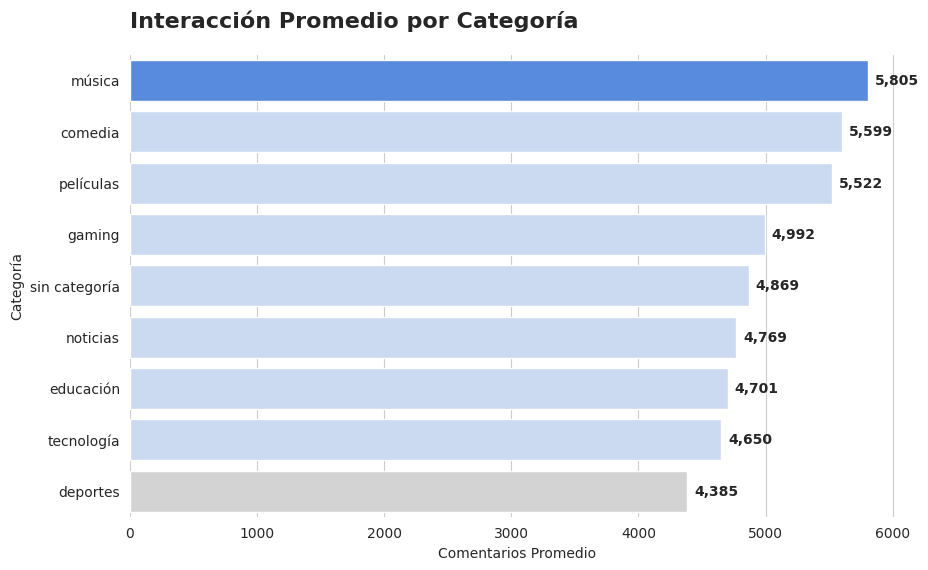

In [50]:
# Realizar gráfico de barras

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax2 = sns.barplot(x=coments_mean.values, y=coments_mean.index, palette=colors_coments, hue=coments_mean.index, legend=False)

for p in ax2.patches: # Etiquetas y estética
    ax2.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Interacción Promedio por Categoría', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Comentarios Promedio')
plt.ylabel('Categoría')
sns.despine(left=True, bottom=True)
plt.show()


## **CHALLENGE: EXPLORACIÓN DE DATOS AIRBNB CDMX**

Una vez visto el ***Hands - On: Exploración de datos***, se presentan las siguientes actividades para que el alumnado pueda repasar y reforzar lo aprendido dentro de la clase.

Para este notebook, se hará uso del siguiente dataset: [enlace](https://drive.google.com/file/d/1HKCV2jFnumpJ1YNFI5cn6wgT2tEiKKfK/view?usp=drive_link)

Dentro de la siguiente dinámica, **se realizará un análisis exploratorio profundo sobre el catálogo de alojamientos de Airbnb en la Ciudad de México** para detectar patrones de comportamiento, valores atípicos y relaciones entre variables. Se hará uso de **herramientas estadísticas, técnicas de detección de outliers y narrativa visual** a través del dataset **"airbnb_clean"**.

Donde los análisis a realizar son:

* **Detección y tratamiento de valores atípicos mediante el rango intercuartílico**.
* **Identificación de relaciones lineales entre variables numéricas**.
* **Comunicación de hallazgos a través de narrativa visual por categoría**.

**IMPORTANTE:** Para su revisión, **es indispensable que los apartados anteriores se encuentren llenados con el código visto durante la sesión.**

### **INSTRUCCIONES:**

**1. Importaciones y análisis de resumen estadístico:**

* Carga las bibliotecas de Pandas, Numpy, Seaborn y Matplotlib.pyplot.
* Carga el archivo *airbnb_clean.csv*.
* Obtén el resumen estadístico de los datos.

In [51]:
# Importar librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración para gráficos más bonitos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print(" Librerías cargadas para análisis de Airbnb")


 Librerías cargadas para análisis de Airbnb


In [92]:
# Importar datos


# Cargar dataset de Airbnb CDMX

url_airbnb = "https://raw.githubusercontent.com/ramsaher/airbnb_cdmx.csv/refs/heads/main/airbnb_cdmx.csv"
df_airbnb = pd.read_csv(url_airbnb)

# Exploración inicial

print(" DATASET DE AIRBNB - CIUDAD DE MÉXICO")
print("="*60)
print(f" Dimensiones: {df_airbnb.shape[0]} filas × {df_airbnb.shape[1]} columnas")
print("\n PRIMERAS 5 FILAS:")
print(df_airbnb.head())
print("\n COLUMNAS DISPONIBLES:")
print(df_airbnb.columns.tolist())

 DATASET DE AIRBNB - CIUDAD DE MÉXICO
 Dimensiones: 27051 filas × 16 columnas

 PRIMERAS 5 FILAS:
      id                                              name  host_id host_name  \
0  35797                                       Villa Dante   153786      Dici   
1  44616                                      Condesa Haus   196253  Fernando   
2  56074              Great space in historical San Rafael   265650     Maris   
3  67703                 2 bedroom apt. deco bldg, Condesa   334451  Nicholas   
4  70644  Beautiful light Studio Coyoacan- full equipped !   212109    Trisha   

           neighbourhood  latitude  longitude        room_type    price  \
0  Cuajimalpa de Morelos  19.38283  -99.27178  Entire home/apt   3673.0   
1             Cuauhtémoc  19.41162  -99.17794  Entire home/apt  18000.0   
2             Cuauhtémoc  19.43977  -99.15605  Entire home/apt    591.0   
3             Cuauhtémoc  19.41152  -99.16857  Entire home/apt      NaN   
4               Coyoacán  19.35448  -99.

In [93]:
# Ver resumen estadístico


print(" RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS:")
print("="*70)
print(df_airbnb.describe())
print("\n" + "="*70)

# Información de tipos de datos y valores nulos

print("\n INFO DEL DATAFRAME:")
print(df_airbnb.info())

# Verificar valores nulos específicamente

print("\n VALORES NULOS POR COLUMNA:")
print(df_airbnb.isnull().sum())


 RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS:
                 id       host_id      latitude     longitude          price  \
count  2.705100e+04  2.705100e+04  27051.000000  27051.000000   23567.000000   
mean   7.003556e+17  2.429439e+08     19.405490    -99.165385    1792.540841   
std    5.702714e+17  2.062579e+08      0.042390      0.033535   13230.940558   
min    3.579700e+04  7.365000e+03     19.177848    -99.339630      61.000000   
25%    4.410472e+07  5.621443e+07     19.392489    -99.178499     643.000000   
50%    8.307368e+17  1.766835e+08     19.415390    -99.167100    1039.000000   
75%    1.217382e+18  4.288830e+08     19.432015    -99.153731    1611.000000   
max    1.518561e+18  7.208445e+08     19.561010    -98.963360  900000.000000   

       minimum_nights  number_of_reviews  reviews_per_month  \
count    27051.000000       27051.000000       23650.000000   
mean         4.580866          53.777679           1.854855   
std         24.784605          85.143043     

**2. Análisis de distribución y filtrado de outliers:**

* Genera un histograma y diagrama de caja sobre la columna `price`.
* Calcula la cantidad de registros con los que cuenta el dataframe.
* Calcula el rango intercuartílico y filtra el dataframe con los registros dentro de los límites.
* Calcula la cantidad y proporción de registros finales y grafica su diagrama de caja.

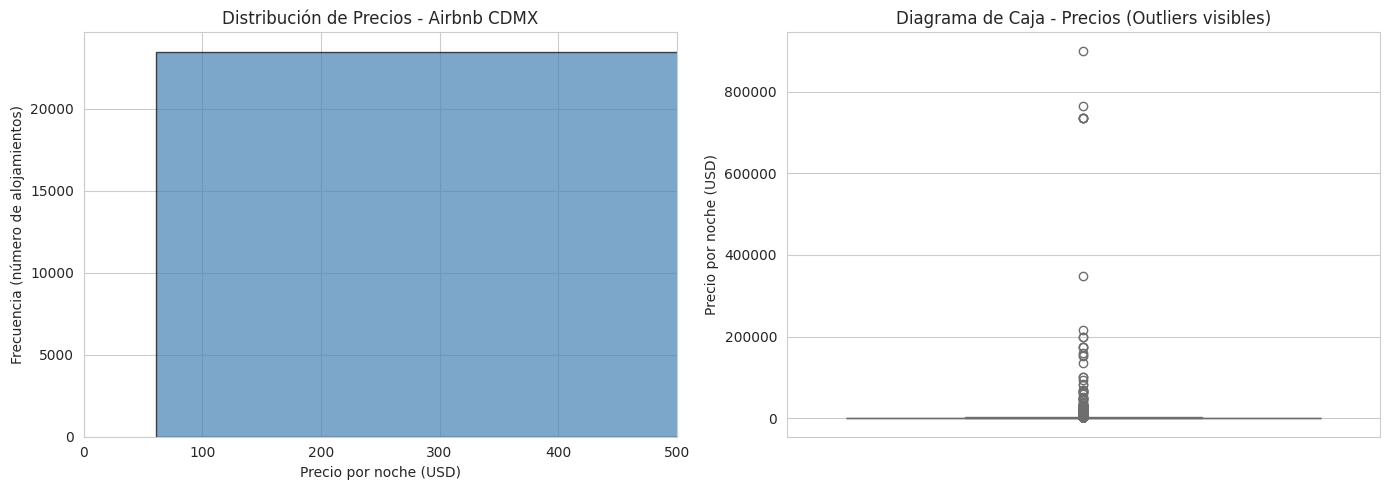

 INTERPRETACIÓN:
- La mayoría de los alojamientos tienen precios bajos
- El boxplot muestra muchos puntos fuera del bigote superior → OUTLIERS
- Estos outliers son alojamientos extremadamente caros


In [56]:
# Observar distribución y comportamiento cuartil de los datos

# DISTRIBUCIÓN DE PRECIOS (HISTOGRAMA Y BOXPLOT)

# Analizar la columna 'price' que contiene el precio por noche

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de precios

axes[0].hist(df_airbnb['price'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Precio por noche (USD)')
axes[0].set_ylabel('Frecuencia (número de alojamientos)')
axes[0].set_title('Distribución de Precios - Airbnb CDMX')
axes[0].set_xlim(0, 500)  # Limitar para mejor visualización

# Boxplot de precios

sns.boxplot(y=df_airbnb['price'], ax=axes[1], color='lightcoral')
axes[1].set_ylabel('Precio por noche (USD)')
axes[1].set_title('Diagrama de Caja - Precios (Outliers visibles)')

plt.tight_layout()
plt.show()

print(" INTERPRETACIÓN:")
print("- La mayoría de los alojamientos tienen precios bajos")
print("- El boxplot muestra muchos puntos fuera del bigote superior → OUTLIERS")
print("- Estos outliers son alojamientos extremadamente caros")


In [57]:
# Ver cantidad de registros iniciales


registros_iniciales = len(df_airbnb)
print(f" REGISTROS INICIALES: {registros_iniciales:,}")

# Ver estadísticas de precio antes de limpiar

print(f"\n ESTADÍSTICAS DE PRECIO (ANTES DE LIMPIAR):")
print(f"  Mínimo: ${df_airbnb['price'].min():.2f}")
print(f"  Mediana: ${df_airbnb['price'].median():.2f}")
print(f"  Media: ${df_airbnb['price'].mean():.2f}")
print(f"  Máximo: ${df_airbnb['price'].max():.2f}")

 REGISTROS INICIALES: 27,051

 ESTADÍSTICAS DE PRECIO (ANTES DE LIMPIAR):
  Mínimo: $61.00
  Mediana: $1039.00
  Media: $1792.54
  Máximo: $900000.00


In [58]:
# Calculo del IQR

# Calcular IQR para la columna 'price'

Q1_price = df_airbnb['price'].quantile(0.25)
Q3_price = df_airbnb['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

limite_inferior_price = Q1_price - 1.5 * IQR_price
limite_superior_price = Q3_price + 1.5 * IQR_price

print("📊 ANÁLISIS DE OUTLIERS - PRECIO")
print(f"  Q1 (25%): ${Q1_price:.2f}")
print(f"  Q3 (75%): ${Q3_price:.2f}")
print(f"  IQR: ${IQR_price:.2f}")
print(f"  Límite Inferior: ${limite_inferior_price:.2f}")
print(f"  Límite Superior: ${limite_superior_price:.2f}")

# Contar outliers

outliers_price = df_airbnb[(df_airbnb['price'] < limite_inferior_price) | (df_airbnb['price'] > limite_superior_price)]
n_outliers = len(outliers_price)
print(f"  Cantidad de Outliers: {n_outliers}")
print(f"  Porcentaje de Outliers: {n_outliers/registros_iniciales*100:.2f}%")


📊 ANÁLISIS DE OUTLIERS - PRECIO
  Q1 (25%): $643.00
  Q3 (75%): $1611.00
  IQR: $968.00
  Límite Inferior: $-809.00
  Límite Superior: $3063.00
  Cantidad de Outliers: 1768
  Porcentaje de Outliers: 6.54%


In [59]:
# Ver cantidad y proporción con la cantidad inicial


# Crear dataframe limpio (sin outliers en precio)

df_airbnb_clean = df_airbnb[
    (df_airbnb['price'] >= limite_inferior_price) &
    (df_airbnb['price'] <= limite_superior_price)
].copy()  # .copy() evita warnings

registros_finales = len(df_airbnb_clean)
proporcion = (registros_finales / registros_iniciales) * 100

print("🔧 RESULTADOS DEL FILTRADO:")
print("="*50)
print(f"  Registros iniciales: {registros_iniciales:,}")
print(f"  Registros finales: {registros_finales:,}")
print(f"  Registros eliminados: {registros_iniciales - registros_finales:,}")
print(f"  Proporción mantenida: {proporcion:.2f}%")


🔧 RESULTADOS DEL FILTRADO:
  Registros iniciales: 27,051
  Registros finales: 21,799
  Registros eliminados: 5,252
  Proporción mantenida: 80.58%


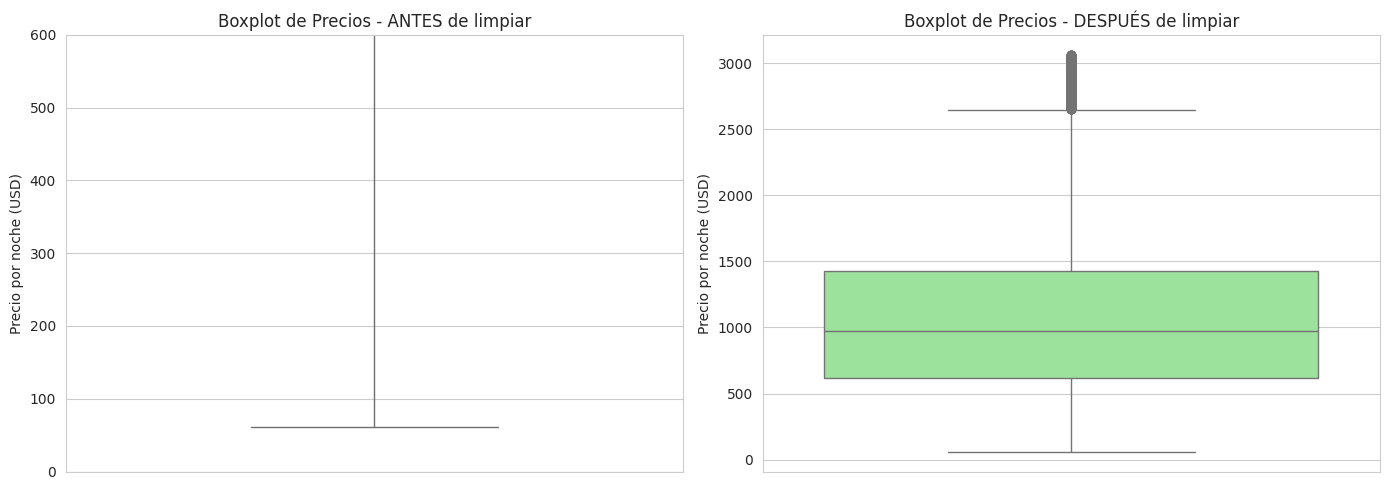

 COMPARACIÓN DE ESTADÍSTICAS - PRECIO
Estadística            Original          Limpio          Cambio
------------------------------------------------------------
Mínimo          $         61.00 $         61.00             ---
Q1              $        643.00 $        616.00           -4.2%
Mediana         $       1039.00 $        976.00           -6.1%
Media           $       1792.54 $       1096.22          -38.8%
Q3              $       1611.00 $       1428.00          -11.4%


In [60]:
# Observar comportamiento cuartil final de los datos

# COMPARACIÓN DE BOXPLOT ANTES/DESPUÉS

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot ANTES
sns.boxplot(y=df_airbnb['price'], ax=axes[0], color='lightcoral')
axes[0].set_title('Boxplot de Precios - ANTES de limpiar')
axes[0].set_ylabel('Precio por noche (USD)')
axes[0].set_ylim(0, 600)

# Boxplot DESPUÉS
sns.boxplot(y=df_airbnb_clean['price'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot de Precios - DESPUÉS de limpiar')
axes[1].set_ylabel('Precio por noche (USD)')

plt.tight_layout()
plt.show()

# Comparación de estadísticas

print(" COMPARACIÓN DE ESTADÍSTICAS - PRECIO")
print("="*60)
print(f"{'Estadística':<15} {'Original':>15} {'Limpio':>15} {'Cambio':>15}")
print("-"*60)
print(f"{'Mínimo':<15} ${df_airbnb['price'].min():>14.2f} ${df_airbnb_clean['price'].min():>14.2f} {'---':>15}")
print(f"{'Q1':<15} ${df_airbnb['price'].quantile(0.25):>14.2f} ${df_airbnb_clean['price'].quantile(0.25):>14.2f} {((df_airbnb_clean['price'].quantile(0.25)/df_airbnb['price'].quantile(0.25)-1)*100):>14.1f}%")
print(f"{'Mediana':<15} ${df_airbnb['price'].median():>14.2f} ${df_airbnb_clean['price'].median():>14.2f} {((df_airbnb_clean['price'].median()/df_airbnb['price'].median()-1)*100):>14.1f}%")
print(f"{'Media':<15} ${df_airbnb['price'].mean():>14.2f} ${df_airbnb_clean['price'].mean():>14.2f} {((df_airbnb_clean['price'].mean()/df_airbnb['price'].mean()-1)*100):>14.1f}%")
print(f"{'Q3':<15} ${df_airbnb['price'].quantile(0.75):>14.2f} ${df_airbnb_clean['price'].quantile(0.75):>14.2f} {((df_airbnb_clean['price'].quantile(0.75)/df_airbnb['price'].quantile(0.75)-1)*100):>14.1f}%")


**3. Análisis de correlaciones:**

* Genera una matriz de correlación sobre las columnas numéricas del dataframe.
* Selecciona las variables numéricas más representativas.
* Realiza correlaciones divididas por categoría segmentadas por la columna `room_type`.

 Columnas numéricas a analizar: ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


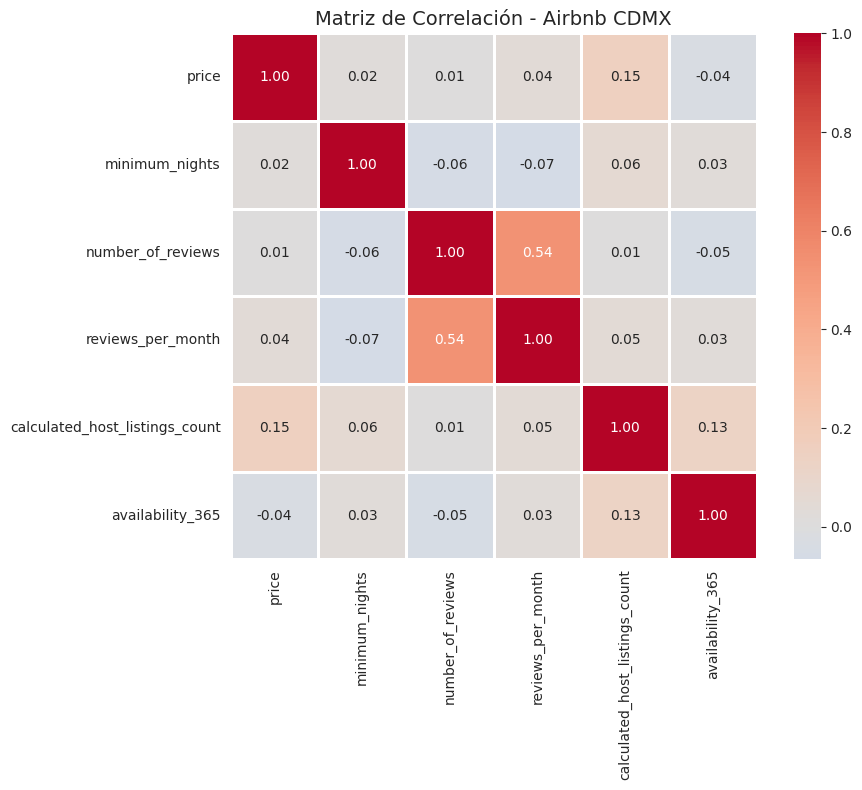


💡 INTERPRETACIÓN DE CORRELACIONES:
- price ↔ number_of_reviews: correlación cercana a 0 → no hay relación
- availability_365 ↔ number_of_reviews: correlación negativa → más disponibilidad = menos reseñas?


In [61]:
# Realizar matriz de correlación

# Seleccionar columnas numéricas relevantes

columnas_numericas = ['price', 'minimum_nights', 'number_of_reviews',
                      'reviews_per_month', 'calculated_host_listings_count',
                      'availability_365']

# Verificar que existan todas las columnas

columnas_existentes = [col for col in columnas_numericas if col in df_airbnb_clean.columns]
print(f" Columnas numéricas a analizar: {columnas_existentes}")

# Calcular matriz de correlación

matriz_corr = df_airbnb_clean[columnas_existentes].corr()

# Visualizar

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr,
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f',
            square=True,
            linewidths=1)
plt.title('Matriz de Correlación - Airbnb CDMX', fontsize=14)
plt.tight_layout()
plt.show()

print("\n💡 INTERPRETACIÓN DE CORRELACIONES:")
print("- price ↔ number_of_reviews: correlación cercana a 0 → no hay relación")
print("- availability_365 ↔ number_of_reviews: correlación negativa → más disponibilidad = menos reseñas?")


In [94]:
# Realizar correlaciones divididas( POR TIPO DE HABITACIÓN)

# Ver tipos de habitación disponibles

print(" TIPOS DE HABITACIÓN EN EL DATASET:")
print(df_airbnb_clean['room_type'].unique())

# Variables a correlacionar
var1 = 'price'
var2 = 'number_of_reviews'

print(f"\n CORRELACIÓN ENTRE {var1} Y {var2} POR TIPO DE HABITACIÓN:")
print("="*60)

for room in df_airbnb_clean['room_type'].unique():
    df_room = df_airbnb_clean[df_airbnb_clean['room_type'] == room]
    if len(df_room) > 10:
        corr = df_room[var1].corr(df_room[var2])
        print(f"  {room:<30}: r = {corr:.3f} (n={len(df_room):,})")


 TIPOS DE HABITACIÓN EN EL DATASET:
['Entire home/apt' 'Private room' 'Hotel room' 'Shared room']

 CORRELACIÓN ENTRE price Y number_of_reviews POR TIPO DE HABITACIÓN:
  Entire home/apt               : r = -0.066 (n=14,389)
  Private room                  : r = -0.066 (n=7,125)
  Hotel room                    : r = -0.336 (n=32)
  Shared room                   : r = 0.029 (n=253)


**4. Regresión lineal simple:**

* Define como variable independiente `reviews_per_month` y como dependiente `number_of_reviews_ltm`.
* Calcula los coeficientes para determinar la ecuación del modelo de regresión lineal simple.
* Ajusta el modelo de regresión lineal con descenso de gradiente y determina la nueva ecuación.
* Visualizar el modelo de regresión lineal ajustada y la curva de perdidas.
* Calcula la reducción del error desde la primera hasta la última época.


In [68]:
# Cálculo de la regresión lineal simple


from sklearn.linear_model import LinearRegression

# Definir variables
# X = variable independiente (predictora)
# y = variable dependiente (a predecir)

X = df_airbnb_clean[['reviews_per_month']].dropna()  # Reseñas por mes
y = df_airbnb_clean.loc[X.index, 'number_of_reviews_ltm']  # Reseñas último año

print(" REGRESIÓN LINEAL SIMPLE")
print(f"  Variable X (independiente): reviews_per_month")
print(f"  Variable y (dependiente): number_of_reviews_ltm")
print(f"  Muestra utilizada: {len(X)} registros")

# Crear y entrenar modelo

modelo = LinearRegression()
modelo.fit(X, y)

# Obtener coeficientes

beta_0 = modelo.intercept_  # Intersección (b)
beta_1 = modelo.coef_[0]    # Pendiente (m)

print(f"\n ECUACIÓN DEL MODELO:")
print(f"  y = {beta_1:.4f} * x + {beta_0:.2f}")
print(f"  Es decir: number_of_reviews_ltm = {beta_1:.4f} × reviews_per_month + {beta_0:.2f}")



 REGRESIÓN LINEAL SIMPLE
  Variable X (independiente): reviews_per_month
  Variable y (dependiente): number_of_reviews_ltm
  Muestra utilizada: 19676 registros

 ECUACIÓN DEL MODELO:
  y = 8.9175 * x + 1.69
  Es decir: number_of_reviews_ltm = 8.9175 × reviews_per_month + 1.69


In [70]:
# Calculo del descenso de gradiente

# El descenso de gradiente es un algoritmo que encuentra los mejores parámetros
# probando diferentes valores y ajustando según el error

def gradient_descent(X, y, learning_rate=0.01, epochs=1000):
    """
    Implementación manual de descenso de gradiente

    Parámetros:
    - X: variable independiente
    - y: variable dependiente
    - learning_rate: qué tan rápido aprendemos (0.01 = 1%)
    - epochs: cuántas iteraciones hacemos

    Retorna: historial de errores y coeficientes finales
    """
    # Inicializar parámetros
    m = 0  # pendiente
    b = 0  # intersección
    n = len(X)

    # Historial para visualizar
    historial_error = []
    historial_m = []
    historial_b = []

    for epoch in range(epochs):
        # Predicción actual
        y_pred = m * X + b

        # Calcular error (MSE - Mean Squared Error)
        error = np.mean((y - y_pred) ** 2)
        historial_error.append(error)
        historial_m.append(m)
        historial_b.append(b)

        # Calcular gradientes (derivadas parciales)
        # Indican en qué dirección ajustar los parámetros

        grad_m = -2 * np.mean(X * (y - y_pred))  # Derivada respecto a m
        grad_b = -2 * np.mean(y - y_pred)        # Derivada respecto a b

        # Actualizar parámetros (paso de actualización)
        m = m - learning_rate * grad_m
        b = b - learning_rate * grad_b

        # Mostrar progreso cada 100 épocas

        if (epoch + 1) % 100 == 0:
            print(f"  Época {epoch+1:4d} | Error: {error:.4f} | m: {m:.4f} | b: {b:.2f}")

    return m, b, historial_error, historial_m, historial_b

# Aplicar descenso de gradiente

print("\n EJECUTANDO DESCENSO DE GRADIENTE:")
print("-"*50)

# Normalizar X para mejor convergencia

X_norm = (X - X.mean()) / X.std()
m_gd, b_gd, errores, ms, bs = gradient_descent(X_norm.values.flatten(), y.values,
                                                learning_rate=0.1, epochs=1000)

print("\n COMPARACIÓN DE MODELOS:")
print(f"  Mínimos Cuadrados (sklearn): y = {beta_1:.4f} * x + {beta_0:.2f}")
print(f"  Descenso de Gradiente:       y = {m_gd:.4f} * x_norm + {b_gd:.2f}")



 EJECUTANDO DESCENSO DE GRADIENTE:
--------------------------------------------------
  Época  100 | Error: 195.1358 | m: 21.3759 | b: 19.66
  Época  200 | Error: 195.1358 | m: 21.3759 | b: 19.66
  Época  300 | Error: 195.1358 | m: 21.3759 | b: 19.66
  Época  400 | Error: 195.1358 | m: 21.3759 | b: 19.66
  Época  500 | Error: 195.1358 | m: 21.3759 | b: 19.66
  Época  600 | Error: 195.1358 | m: 21.3759 | b: 19.66
  Época  700 | Error: 195.1358 | m: 21.3759 | b: 19.66
  Época  800 | Error: 195.1358 | m: 21.3759 | b: 19.66
  Época  900 | Error: 195.1358 | m: 21.3759 | b: 19.66
  Época 1000 | Error: 195.1358 | m: 21.3759 | b: 19.66

 COMPARACIÓN DE MODELOS:
  Mínimos Cuadrados (sklearn): y = 8.9175 * x + 1.69
  Descenso de Gradiente:       y = 21.3759 * x_norm + 19.66


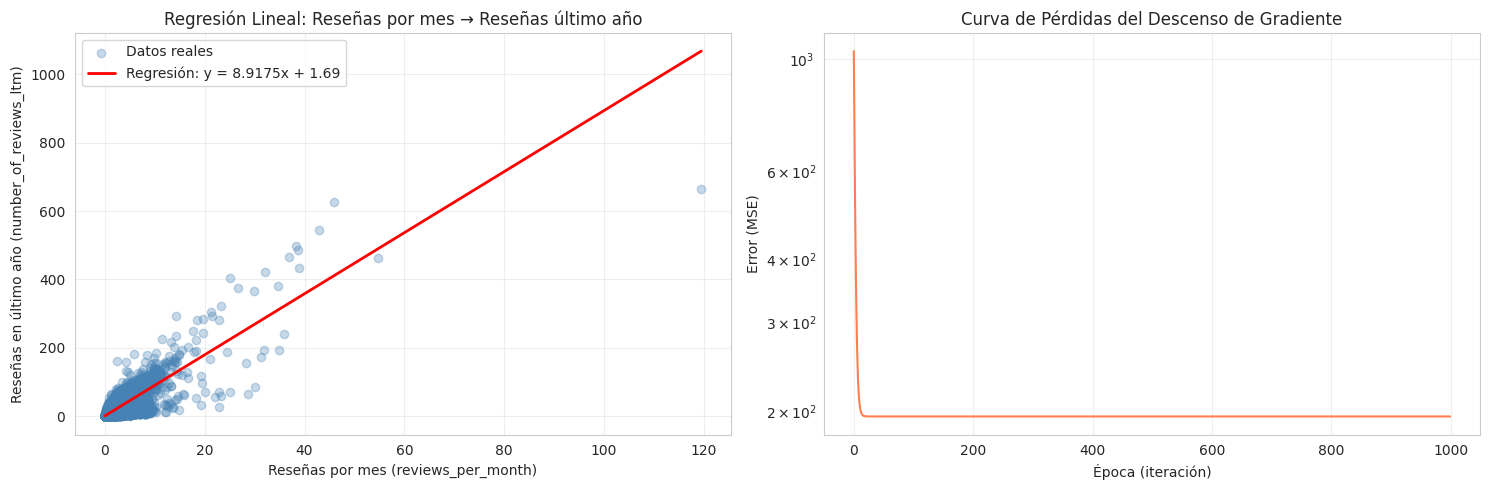

 INTERPRETACIÓN DE LA CURVA DE PÉRDIDAS:
- El error disminuye rápidamente al principio
- Luego se estabiliza (converge a un mínimo)
- Esto indica que el algoritmo está aprendiendo correctamente


In [71]:
# Visualizar regresión lineal y perdidas

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Regresión lineal
ax1.scatter(X, y, alpha=0.3, color='steelblue', label='Datos reales')
# Línea de regresión con sklearn
x_line = np.linspace(X.min(), X.max(), 100)
y_line = beta_1 * x_line + beta_0
ax1.plot(x_line, y_line, 'r-', linewidth=2, label=f'Regresión: y = {beta_1:.4f}x + {beta_0:.2f}')
ax1.set_xlabel('Reseñas por mes (reviews_per_month)')
ax1.set_ylabel('Reseñas en último año (number_of_reviews_ltm)')
ax1.set_title('Regresión Lineal: Reseñas por mes → Reseñas último año')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Curva de pérdidas (error a través del tiempo)
ax2.plot(errores, color='coral', linewidth=1.5)
ax2.set_xlabel('Época (iteración)')
ax2.set_ylabel('Error (MSE)')
ax2.set_title('Curva de Pérdidas del Descenso de Gradiente')
ax2.set_yscale('log')  # Escala logarítmica para ver mejor
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" INTERPRETACIÓN DE LA CURVA DE PÉRDIDAS:")
print("- El error disminuye rápidamente al principio")
print("- Luego se estabiliza (converge a un mínimo)")
print("- Esto indica que el algoritmo está aprendiendo correctamente")



In [72]:
# Registro final de perdida

# REDUCCIÓN DEL ERROR

error_inicial = errores[0]
error_final = errores[-1]
reduccion = (error_inicial - error_final) / error_inicial * 100

print(" ANÁLISIS DE LA REDUCCIÓN DEL ERROR:")
print("="*50)
print(f"  Error en época 1 (inicial):  {error_inicial:.4f}")
print(f"  Error en época final:         {error_final:.4f}")
print(f"  Reducción absoluta:           {error_inicial - error_final:.4f}")
print(f"  Reducción porcentual:         {reduccion:.2f}%")
print("="*50)

if reduccion > 90:
    print(" ¡Excelente! El modelo redujo el error en más del 90%")
elif reduccion > 70:
    print(" Bueno: El modelo redujo significativamente el error")
else:
    print(" Podría necesitar más épocas o ajustar learning_rate")


 ANÁLISIS DE LA REDUCCIÓN DEL ERROR:
  Error en época 1 (inicial):  1038.7304
  Error en época final:         195.1358
  Reducción absoluta:           843.5947
  Reducción porcentual:         81.21%
 Bueno: El modelo redujo significativamente el error


**5. Comparación por categoría:**

* Utiliza un gráfico de barras para mostrar el precio promedio por tipo de habitación.
* Utiliza un diagrama de caja para visualizar la distribución del precio por tipo de habitación.
* Agrupa el dataframe por la columna `room_type` y calcula el conteo de alojamientos.
* Utiliza un gráfico de dona que muestre el porcentaje de cada categoría.

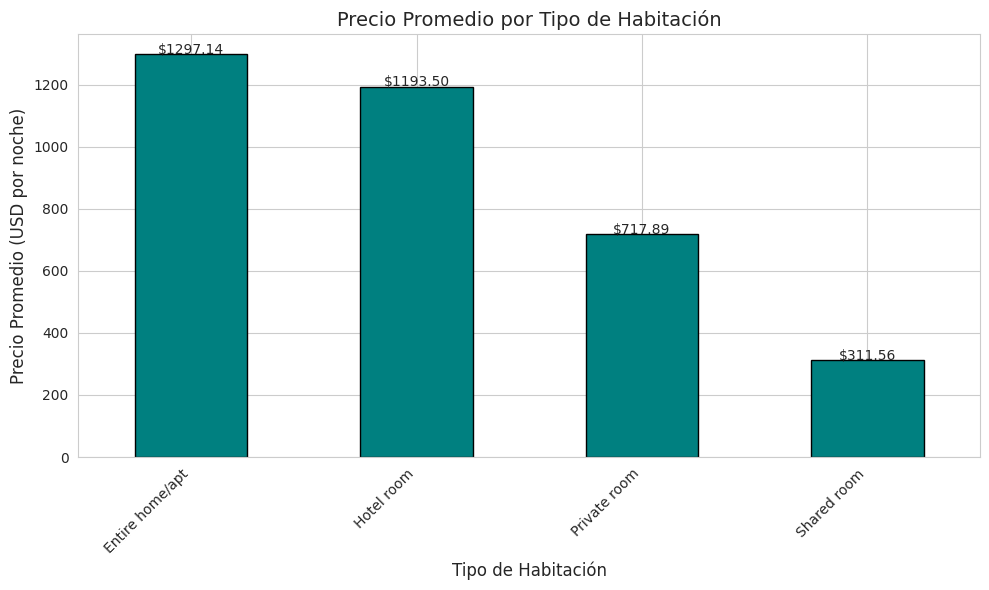

 PRECIO PROMEDIO POR TIPO:
  Entire home/apt: $1297.14
  Hotel room: $1193.50
  Private room: $717.89
  Shared room: $311.56


In [73]:
# Realizar gráficos de barras divididas(PRECIO PROMEDIO POR TIPO DE HABITACIÓN)

# Gráfico de barras
precio_por_tipo = df_airbnb_clean.groupby('room_type')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
precio_por_tipo.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Precio Promedio por Tipo de Habitación', fontsize=14)
plt.xlabel('Tipo de Habitación', fontsize=12)
plt.ylabel('Precio Promedio (USD por noche)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Agregar etiquetas con los valores
for i, v in enumerate(precio_por_tipo):
    plt.text(i, v + 2, f'${v:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(" PRECIO PROMEDIO POR TIPO:")
for tipo, precio in precio_por_tipo.items():
    print(f"  {tipo}: ${precio:.2f}")



/tmp/ipykernel_2250/331913894.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_airbnb_clean, x='room_type', y='price', palette='Set2')


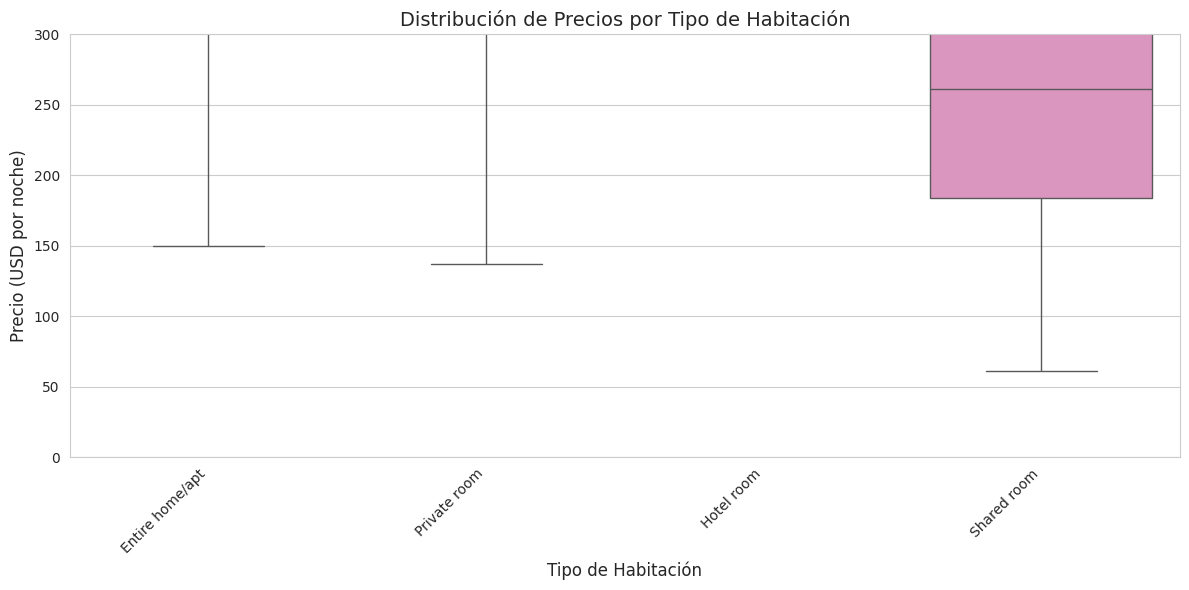

 INTERPRETACIÓN DEL BOXPLOT:
- 'Entire home/apt' tiene la mediana más alta y mayor dispersión
- 'Shared room' tiene los precios más bajos
- Todos los tipos tienen outliers (puntos fuera de los bigotes)


In [88]:
# DIAGRAMA DE CAJA POR TIPO DE HABITACIÓN

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_airbnb_clean, x='room_type', y='price', palette='Set2')
plt.title('Distribución de Precios por Tipo de Habitación', fontsize=14)
plt.xlabel('Tipo de Habitación', fontsize=12)
plt.ylabel('Precio (USD por noche)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 300)  # Limitar para mejor visualización

plt.tight_layout()
plt.show()

print(" INTERPRETACIÓN DEL BOXPLOT:")
print("- 'Entire home/apt' tiene la mediana más alta y mayor dispersión")
print("- 'Shared room' tiene los precios más bajos")
print("- Todos los tipos tienen outliers (puntos fuera de los bigotes)")

In [89]:
# Definir variables para la agrupación (CONTEO DE ALOJAMIENTOS POR CATEGORÍA)

# Agrupar y contar
conteo_tipo = df_airbnb_clean['room_type'].value_counts()

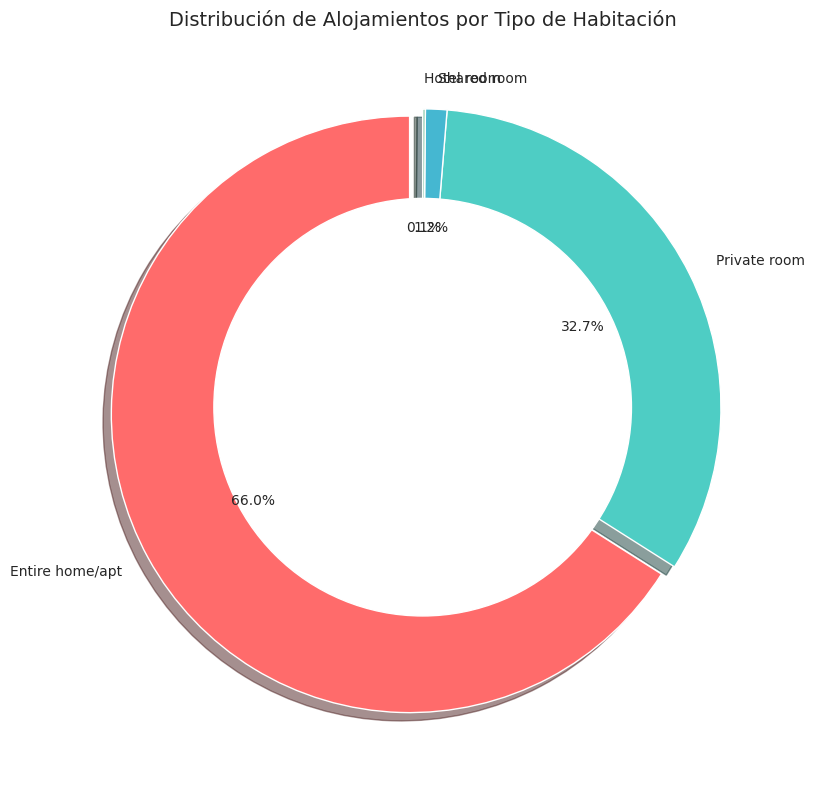

 DISTRIBUCIÓN DE ALOJAMIENTOS:
  Entire home/apt: 14,389 (66.0%)
  Private room: 7,125 (32.7%)
  Shared room: 253 (1.2%)
  Hotel room: 32 (0.1%)


In [90]:
# Realizar gráfico de dona

# Preparar datos para gráfico de dona

plt.figure(figsize=(10, 8))
colores = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
explode = (0.05, 0, 0, 0)  # Resaltar la categoría más grande

plt.pie(conteo_tipo,
        labels=conteo_tipo.index,
        autopct='%1.1f%%',
        colors=colores,
        explode=explode,
        startangle=90,
        shadow=True)

# Crear efecto dona

centre_circle = plt.Circle((0,0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

plt.title('Distribución de Alojamientos por Tipo de Habitación', fontsize=14)
plt.tight_layout()
plt.show()

print(" DISTRIBUCIÓN DE ALOJAMIENTOS:")
for tipo, cantidad in conteo_tipo.items():
    porcentaje = cantidad / len(df_airbnb_clean) * 100
    print(f"  {tipo}: {cantidad:,} ({porcentaje:.1f}%)")



**6. Narrativa visual:**

* Utiliza un gráfico de barras horizontales para mostrar el conteo de alojamientos por alcaldía.
* Utiliza un gráfico de barras horizontales para mostrar el precio promedio por alcaldía.
* Utiliza un gráfico de barras horizontales para mostrar el promedio de reseñas por alcaldía.

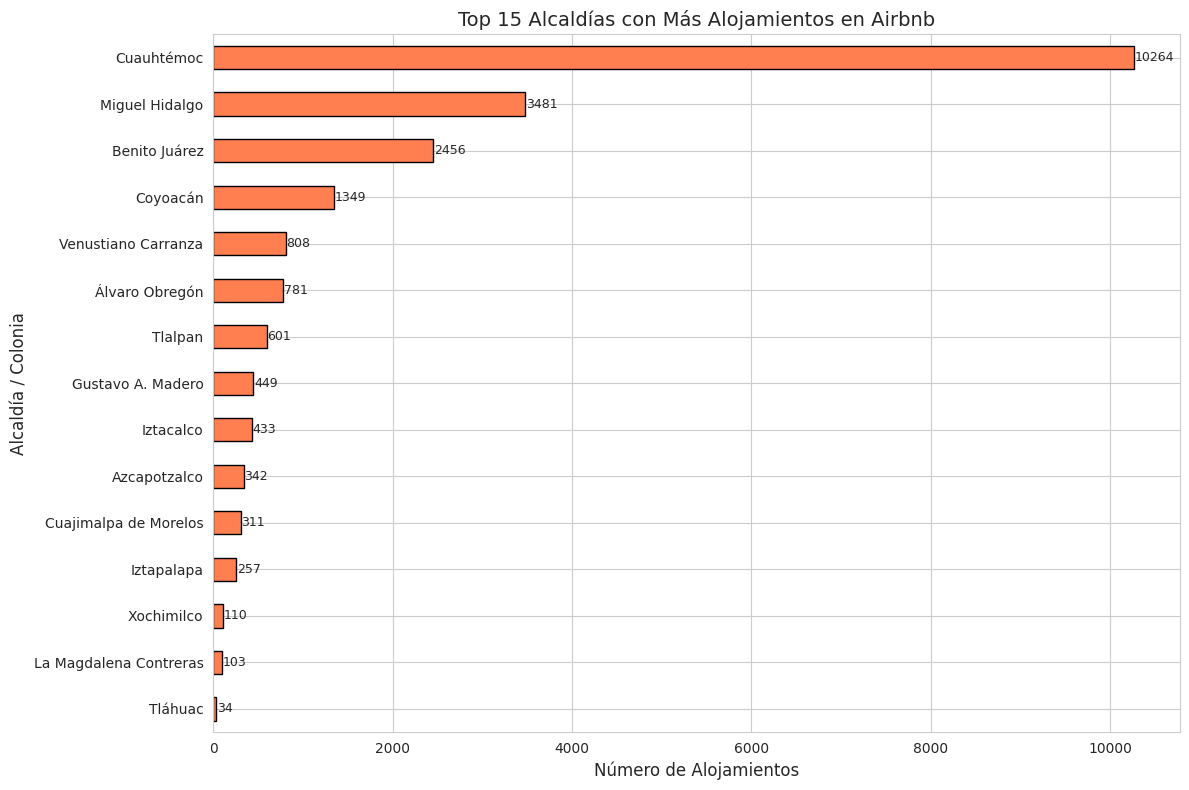

 TOP 5 ALCALDÍAS CON MÁS ALOJAMIENTOS:
  1. Cuauhtémoc: 10264 alojamientos
  2. Miguel Hidalgo: 3481 alojamientos
  3. Benito Juárez: 2456 alojamientos
  4. Coyoacán: 1349 alojamientos
  5. Venustiano Carranza: 808 alojamientos


In [91]:
# Realizar gráfico de barras

# Conteo por Alojamiento por alcaldia (BARRAS HORIZONTALES)
# Gráfico de barras horizontales para mejor legibilidad de nombres largos
conteo_alcaldia = df_airbnb_clean['neighbourhood'].value_counts().head(15)

plt.figure(figsize=(12, 8))
conteo_alcaldia.sort_values().plot(kind='barh', color='coral', edgecolor='black')
plt.title('Top 15 Alcaldías con Más Alojamientos en Airbnb', fontsize=14)
plt.xlabel('Número de Alojamientos', fontsize=12)
plt.ylabel('Alcaldía / Colonia', fontsize=12)

# Agregar etiquetas
for i, v in enumerate(conteo_alcaldia.sort_values().items()):
    plt.text(v[1] + 5, i, str(v[1]), va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(" TOP 5 ALCALDÍAS CON MÁS ALOJAMIENTOS:")
for i, (alcaldia, count) in enumerate(conteo_alcaldia.head(5).items()):
    print(f"  {i+1}. {alcaldia}: {count} alojamientos")

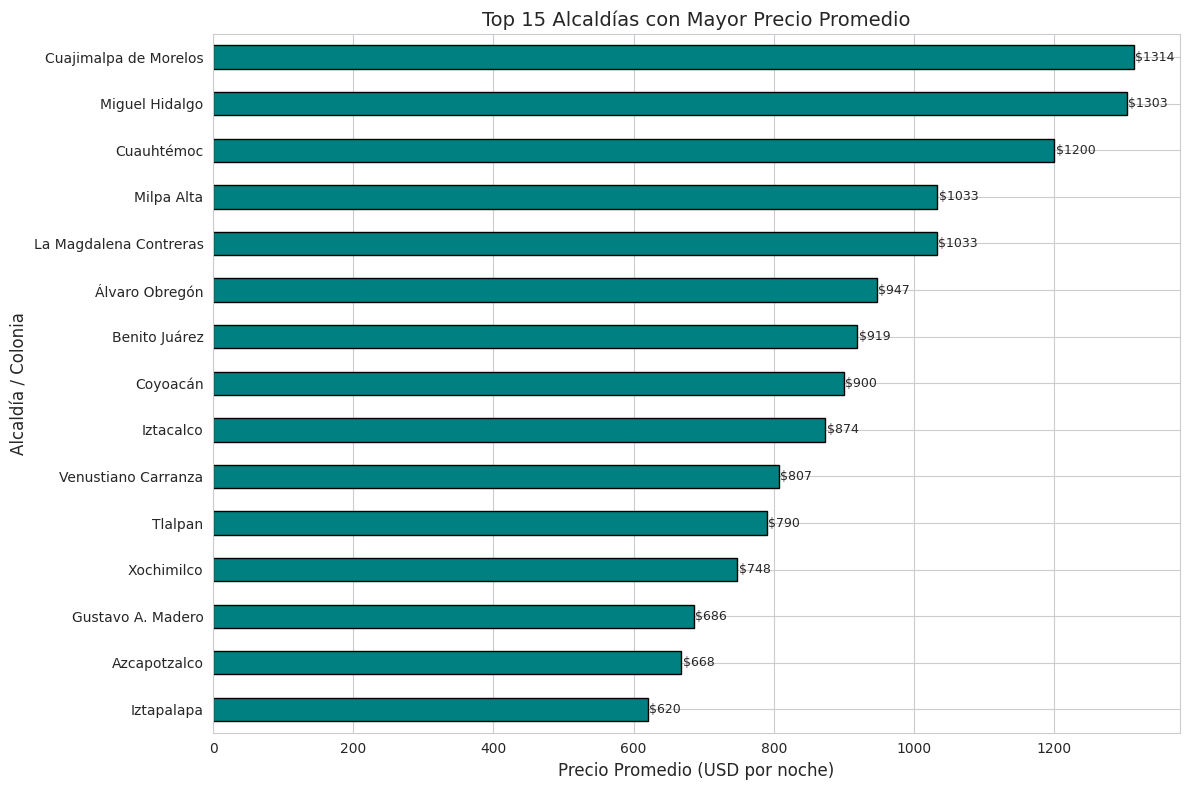

 TOP 5 ALCALDÍAS MÁS CARAS:
  1. Cuajimalpa de Morelos: $1313.82 por noche
  2. Miguel Hidalgo: $1303.34 por noche
  3. Cuauhtémoc: $1200.06 por noche
  4. Milpa Alta: $1033.05 por noche
  5. La Magdalena Contreras: $1032.87 por noche


In [84]:
# Realizar gráfico de barras (PRECIO PROMEDIO POR ALCALDÍA)


precio_alcaldia = df_airbnb_clean.groupby('neighbourhood')['price'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
precio_alcaldia.sort_values().plot(kind='barh', color='teal', edgecolor='black')
plt.title('Top 15 Alcaldías con Mayor Precio Promedio', fontsize=14)
plt.xlabel('Precio Promedio (USD por noche)', fontsize=12)
plt.ylabel('Alcaldía / Colonia', fontsize=12)

# Agregar etiquetas con formato de moneda
for i, v in enumerate(precio_alcaldia.sort_values().items()):
    plt.text(v[1] + 2, i, f'${v[1]:.0f}', va='center', fontsize=9)


plt.tight_layout()
plt.show()

print(" TOP 5 ALCALDÍAS MÁS CARAS:")
for i, (alcaldia, precio) in enumerate(precio_alcaldia.head(5).items()):
    print(f"  {i+1}. {alcaldia}: ${precio:.2f} por noche")

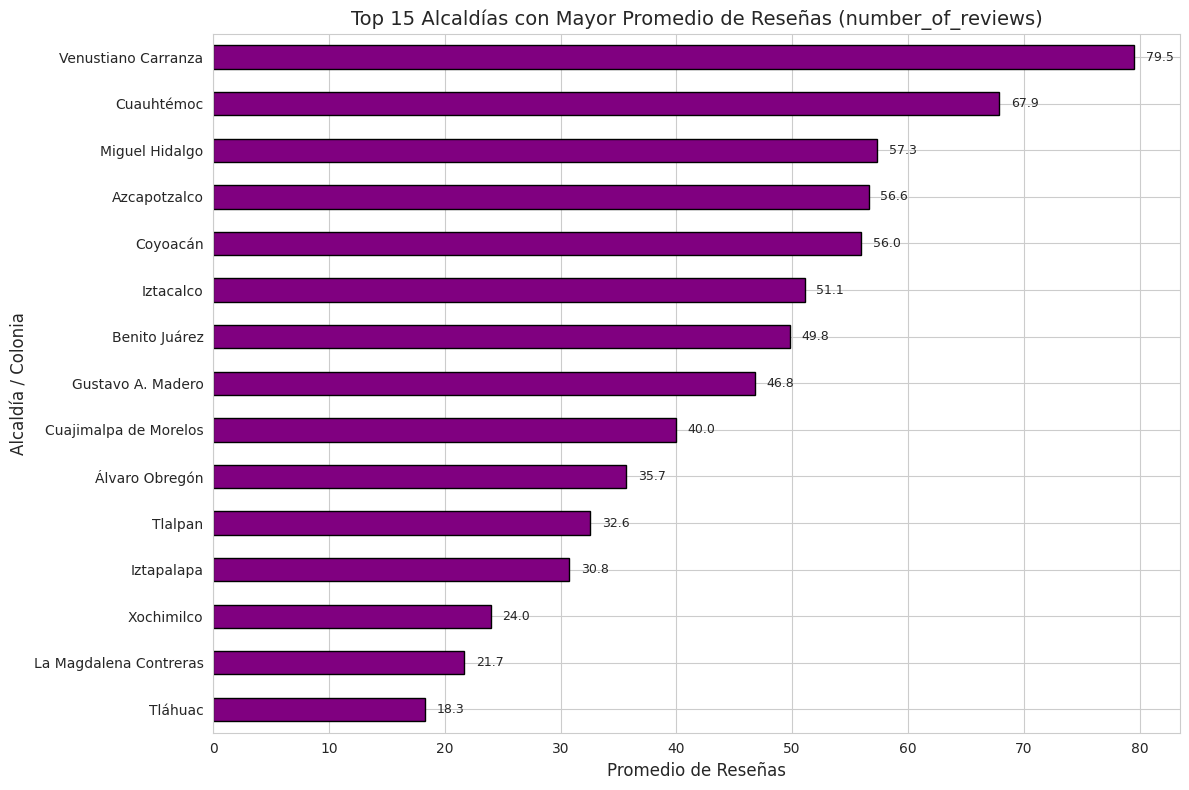

 TOP 5 ALCALDÍAS CON MÁS RESEÑAS:
  1. Venustiano Carranza: 79.5 reseñas promedio
  2. Cuauhtémoc: 67.9 reseñas promedio
  3. Miguel Hidalgo: 57.3 reseñas promedio
  4. Azcapotzalco: 56.6 reseñas promedio
  5. Coyoacán: 56.0 reseñas promedio


In [87]:
# Realizar gráfico de barras(PROMEDIO DE RESEÑAS POR ALCALDÍA)

# Si 'number_of_reviews' existe, usamos esa columna
columna_resenas = 'number_of_reviews' if 'number_of_reviews' in df_airbnb_clean.columns else 'reviews_per_month'

resenas_alcaldia = df_airbnb_clean.groupby('neighbourhood')[columna_resenas].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
resenas_alcaldia.sort_values().plot(kind='barh', color='purple', edgecolor='black')
plt.title(f'Top 15 Alcaldías con Mayor Promedio de Reseñas ({columna_resenas})', fontsize=14)
plt.xlabel('Promedio de Reseñas', fontsize=12)
plt.ylabel('Alcaldía / Colonia', fontsize=12)

for i, v in enumerate(resenas_alcaldia.sort_values().items()):
    plt.text(v[1] + 1, i, f'{v[1]:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(" TOP 5 ALCALDÍAS CON MÁS RESEÑAS:")
for i, (alcaldia, resenas) in enumerate(resenas_alcaldia.head(5).items()):
    print(f"  {i+1}. {alcaldia}: {resenas:.1f} reseñas promedio")